In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive



===== Running ACO for KNN =====


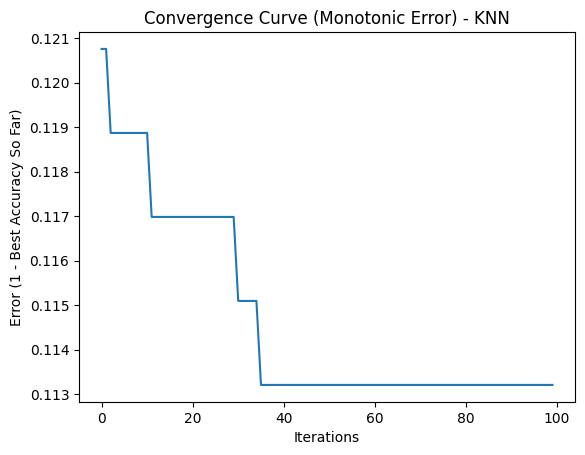

Selected Features: [0, 1, 2, 4, 5, 6, 9, 10, 11, 12, 13, 14, 15, 16, 18, 20, 21, 22, 23, 25, 26, 27, 28, 29, 30, 31, 32, 33, 35, 37]
Without FS: {'Accuracy': 0.8333333333333334, 'Precision': 0.0, 'Recall': 0.0, 'F1': 0.0}
With FS: {'Accuracy': 0.8636363636363636, 'Precision': 0.0, 'Recall': 0.0, 'F1': 0.0}

===== Running ACO for Naive Bayes =====


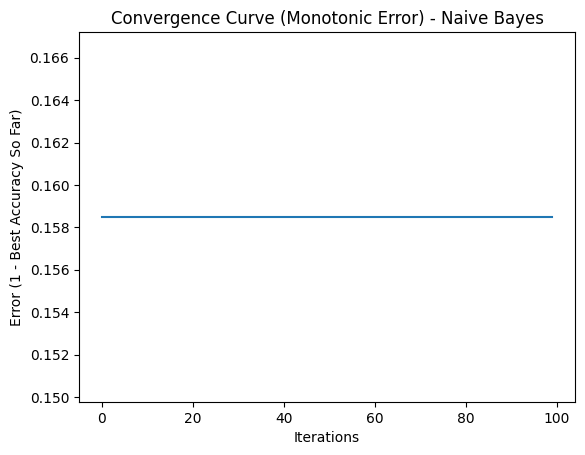

Selected Features: [1, 2, 3, 4, 7, 8, 9, 10, 11, 12, 13, 14, 15, 17, 18, 19, 20, 21, 23, 25, 26, 27, 29, 30, 31, 32, 33, 34, 35, 36, 37]
Without FS: {'Accuracy': 0.803030303030303, 'Precision': 0.14285714285714285, 'Recall': 0.125, 'F1': 0.13333333333333333}
With FS: {'Accuracy': 0.803030303030303, 'Precision': 0.14285714285714285, 'Recall': 0.125, 'F1': 0.13333333333333333}

===== Running ACO for QDA =====


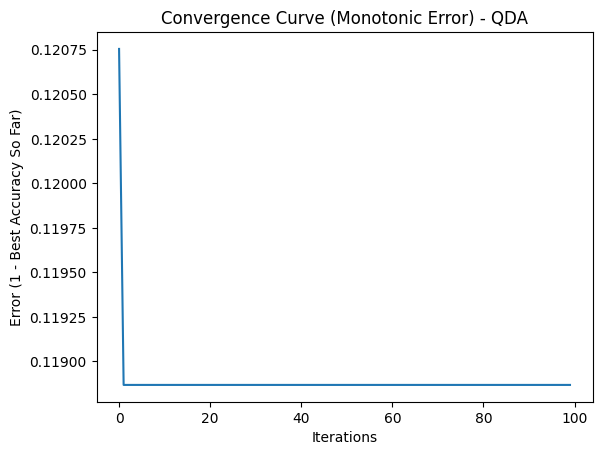

Selected Features: [0, 1, 2, 3, 5, 7, 8, 9, 10, 11, 12, 14, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37]
Without FS: {'Accuracy': 0.8636363636363636, 'Precision': 0.0, 'Recall': 0.0, 'F1': 0.0}
With FS: {'Accuracy': 0.8181818181818182, 'Precision': 0.16666666666666666, 'Recall': 0.125, 'F1': 0.14285714285714285}

===== Running ACO for Random Forest =====


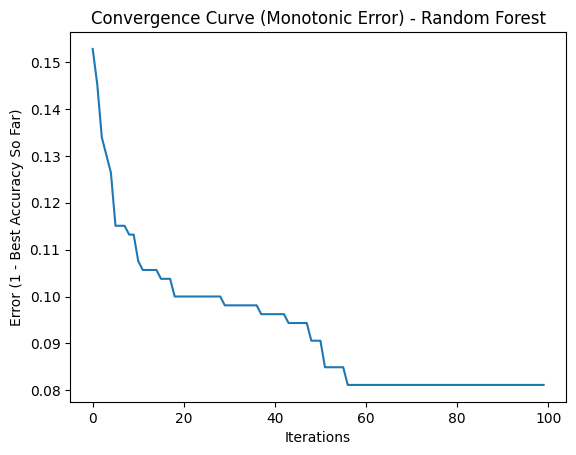

Selected Features: [0, 1, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37]
Without FS: {'Accuracy': 0.8333333333333334, 'Precision': 0.2, 'Recall': 0.125, 'F1': 0.15384615384615385}
With FS: {'Accuracy': 0.7878787878787878, 'Precision': 0.2, 'Recall': 0.25, 'F1': 0.2222222222222222}

===== FINAL RESULT TABLE =====
           Model  Accuracy (No FS)  Accuracy (With FS)  Precision  Recall  \
0            KNN          0.833333            0.863636   0.000000   0.000   
1    Naive Bayes          0.803030            0.803030   0.142857   0.125   
2            QDA          0.863636            0.818182   0.166667   0.125   
3  Random Forest          0.833333            0.787879   0.200000   0.250   

         F1  
0  0.000000  
1  0.133333  
2  0.142857  
3  0.222222  


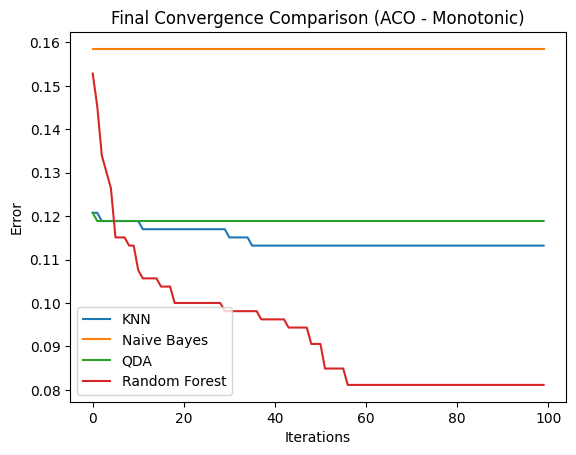


  Avg Execution Time : 374.0069 s
  Avg Memory Used    : 0.7015 MB


In [ ]:
# =========================
# FINAL WRAPPER ACO (MONOTONIC CONVERGENCE) - CM1
# =========================

import numpy as np
import pandas as pd
import random
import time
import tracemalloc
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier

# =========================
# LOAD DATA
# =========================
path = "/content/drive/MyDrive/DATASETS/csv_result-CM1.csv"
df = pd.read_csv(path)

df = df.drop(columns=['name'], errors='ignore')

target_col = df.columns[-1]

X = df.drop(columns=[target_col])
y = df[target_col].map({'N': 0, 'Y': 1})

# =========================
# SPLIT (NO DATA LEAKAGE)
# =========================
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# =========================
# MODELS
# =========================
models = {
    "KNN": KNeighborsClassifier(n_jobs=-1),
    "Naive Bayes": GaussianNB(),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1),
    "Random Forest": RandomForestClassifier(
        n_estimators=5,
        max_depth=5,
        n_jobs=-1,
        class_weight='balanced'
    )
}

# =========================
# ACO PARAMETERS
# =========================
NUM_ANTS = 10
ITERATIONS = 100
REPEATS = 10

EVAPORATION = 0.3
num_features = X_train.shape[1]

# =========================
# FITNESS (penalized)
# =========================
fitness_cache = {}

def fitness(solution, model):
    key = tuple(solution)

    if key in fitness_cache:
        return fitness_cache[key]

    if sum(solution) < 3:
        return 0

    selected = [i for i in range(len(solution)) if solution[i] == 1]

    X_tr = X_train[:, selected]
    X_v = X_val[:, selected]

    model.fit(X_tr, y_train)
    pred = model.predict(X_v)

    acc = accuracy_score(y_val, pred)

    feature_ratio = sum(solution) / num_features
    score = acc - 0.3 * feature_ratio

    fitness_cache[key] = score
    return score

# =========================
# CONSTRUCT SOLUTION
# =========================
def construct_solution(pheromone):
    solution = []

    for i in range(num_features):
        prob = pheromone[i] / (1 + pheromone[i])
        solution.append(1 if random.random() < prob else 0)

    return np.array(solution)

# =========================
# RUN ACO
# =========================
results = []
Total_time = []
Total_memory = []
model_curves = {}

for model_name, model in models.items():

    print(f"\n===== Running ACO for {model_name} =====")

    all_curves = []

    tracemalloc.start()
    start_time = time.time()

    best_global = None
    best_score = -1

    for r in range(REPEATS):

        pheromone = np.ones(num_features)
        curve = []
        best_so_far = 0   # 🔥 key for monotonic graph

        for it in range(ITERATIONS):

            solutions = []
            scores = []
            acc_list = []

            for ant in range(NUM_ANTS):
                sol = construct_solution(pheromone)

                selected = [i for i in range(len(sol)) if sol[i] == 1]

                if len(selected) < 3:
                    acc = 0
                else:
                    model.fit(X_train[:, selected], y_train)
                    pred = model.predict(X_val[:, selected])
                    acc = accuracy_score(y_val, pred)

                acc_list.append(acc)

                feature_ratio = sum(sol) / num_features
                score = acc - 0.3 * feature_ratio

                solutions.append(sol)
                scores.append(score)

            # pheromone update
            pheromone = (1 - EVAPORATION) * pheromone
            for sol, score in zip(solutions, scores):
                pheromone += score * sol

            # 🔥 MONOTONIC CONVERGENCE
            best_acc = max(acc_list)
            best_so_far = max(best_so_far, best_acc)

            curve.append(1 - best_so_far)   # error

        all_curves.append(curve)

        best_idx = np.argmax(scores)
        if scores[best_idx] > best_score:
            best_score = scores[best_idx]
            best_global = solutions[best_idx]

    # Time & Memory
    end_time = time.time()
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    Total_time.append(end_time - start_time)
    Total_memory.append(peak / 10**6)

    # Mean curve
    mean_curve = np.mean(all_curves, axis=0)
    model_curves[model_name] = mean_curve

    plt.figure()
    plt.plot(mean_curve)
    plt.title(f"Convergence Curve (Monotonic Error) - {model_name}")
    plt.xlabel("Iterations")
    plt.ylabel("Error (1 - Best Accuracy So Far)")
    plt.show()

    # Selected features
    selected_features = [i for i in range(len(best_global)) if best_global[i] == 1]
    if len(selected_features) == 0:
        selected_features = list(range(num_features))

    print("Selected Features:", selected_features)

    # =========================
    # FINAL EVALUATION
    # =========================
    def evaluate(model, X_tr, X_te):
        model.fit(X_tr, y_train_full)
        pred = model.predict(X_te)

        return {
            "Accuracy": accuracy_score(y_test, pred),
            "Precision": precision_score(y_test, pred, zero_division=0),
            "Recall": recall_score(y_test, pred, zero_division=0),
            "F1": f1_score(y_test, pred, zero_division=0)
        }

    res1 = evaluate(model, scaler.transform(X_train_full), X_test)

    X_train_fs = scaler.transform(X_train_full)[:, selected_features]
    X_test_fs = X_test[:, selected_features]

    res2 = evaluate(model, X_train_fs, X_test_fs)

    print("Without FS:", res1)
    print("With FS:", res2)

    results.append([
        model_name,
        res1["Accuracy"], res2["Accuracy"],
        res2["Precision"], res2["Recall"], res2["F1"]
    ])

# =========================
# FINAL TABLE
# =========================
final_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy (No FS)", "Accuracy (With FS)",
    "Precision", "Recall", "F1"
])

print("\n===== FINAL RESULT TABLE =====")
print(final_df)

# =========================
# FINAL CONVERGENCE GRAPH
# =========================
plt.figure()

for model_name, curve in model_curves.items():
    plt.plot(curve, label=model_name)

plt.title("Final Convergence Comparison (ACO - Monotonic)")
plt.xlabel("Iterations")
plt.ylabel("Error")
plt.legend()
plt.show()

# =========================
# TIME & MEMORY
# =========================
print(f"\n  Avg Execution Time : {np.mean(Total_time):.4f} s")
print(f"  Avg Memory Used    : {np.mean(Total_memory):.4f} MB")


===== Running ACO for KNN =====


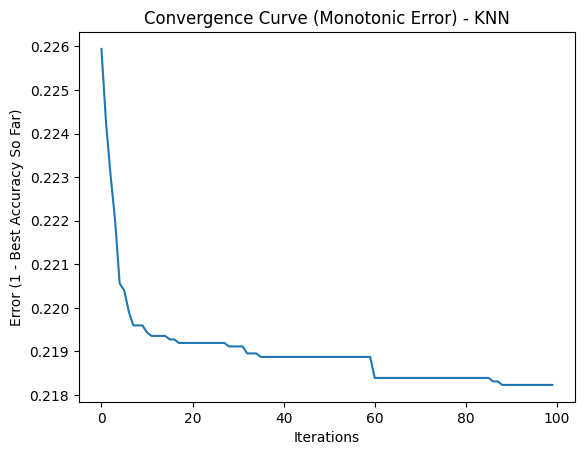

Selected Features: [1, 2, 3, 4, 6, 7, 8, 9, 10, 11, 12, 14, 16, 17, 18, 19, 20, 21]
Without FS: {'Accuracy': 0.7559409120102761, 'Precision': 0.35668789808917195, 'Recall': 0.16716417910447762, 'F1': 0.22764227642276422}
With FS: {'Accuracy': 0.7540141297366731, 'Precision': 0.36363636363636365, 'Recall': 0.191044776119403, 'F1': 0.25048923679060664}

===== Running ACO for Naive Bayes =====


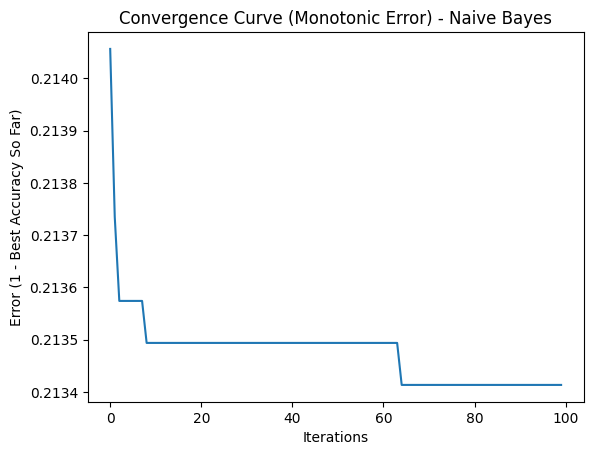

Selected Features: [0, 1, 2, 4, 5, 6, 7, 8, 9, 11, 12, 13, 14, 15, 16, 17, 18, 21]
Without FS: {'Accuracy': 0.7745664739884393, 'Precision': 0.4393939393939394, 'Recall': 0.17313432835820897, 'F1': 0.24839400428265523}
With FS: {'Accuracy': 0.7739242132305716, 'Precision': 0.4297520661157025, 'Recall': 0.15522388059701492, 'F1': 0.22807017543859648}

===== Running ACO for QDA =====


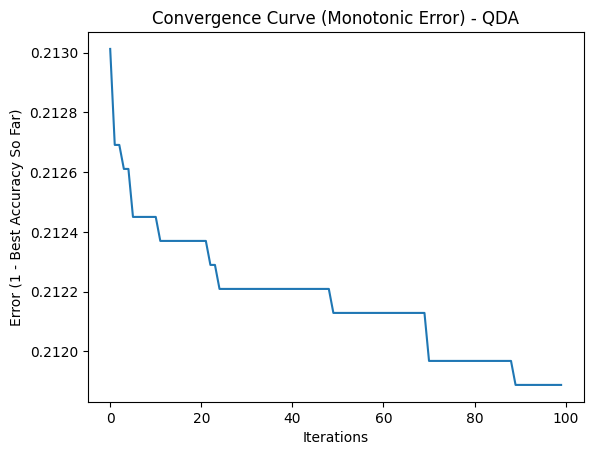

Selected Features: [2, 4, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 21]
Without FS: {'Accuracy': 0.7790622992935131, 'Precision': 0.45714285714285713, 'Recall': 0.14328358208955225, 'F1': 0.21818181818181817}
With FS: {'Accuracy': 0.7739242132305716, 'Precision': 0.40860215053763443, 'Recall': 0.11343283582089553, 'F1': 0.17757009345794392}

===== Running ACO for Random Forest =====


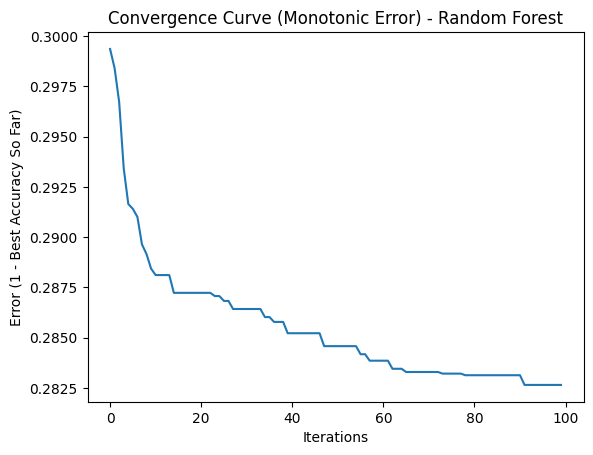

Selected Features: [1, 2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 17, 18, 19, 20]
Without FS: {'Accuracy': 0.6621708413615928, 'Precision': 0.3327495621716287, 'Recall': 0.5671641791044776, 'F1': 0.4194260485651214}
With FS: {'Accuracy': 0.6518946692357097, 'Precision': 0.318739054290718, 'Recall': 0.5432835820895522, 'F1': 0.40176600441501104}

===== FINAL RESULT TABLE =====
           Model  Accuracy (No FS)  Accuracy (With FS)  Precision    Recall  \
0            KNN          0.755941            0.754014   0.363636  0.191045   
1    Naive Bayes          0.774566            0.773924   0.429752  0.155224   
2            QDA          0.779062            0.773924   0.408602  0.113433   
3  Random Forest          0.662171            0.651895   0.318739  0.543284   

         F1  
0  0.250489  
1  0.228070  
2  0.177570  
3  0.401766  


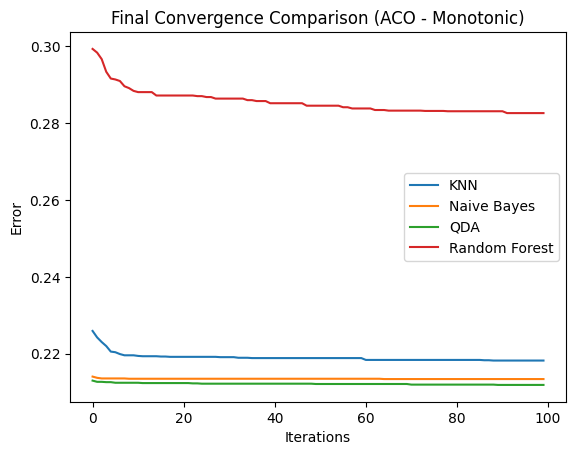


  Avg Execution Time : 586.3231 s
  Avg Memory Used    : 3.0481 MB


In [ ]:
# =========================
# FINAL WRAPPER ACO (MONOTONIC CONVERGENCE) - JM1
# =========================

import numpy as np
import pandas as pd
import random
import time
import tracemalloc
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier

# =========================
# LOAD DATA
# =========================
path = "/content/drive/MyDrive/DATASETS/csv_result-JM1.csv"
df = pd.read_csv(path)

df = df.drop(columns=['name'], errors='ignore')

target_col = df.columns[-1]

X = df.drop(columns=[target_col])
y = df[target_col].map({'N': 0, 'Y': 1})

# =========================
# SPLIT (NO DATA LEAKAGE)
# =========================
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# =========================
# MODELS
# =========================
models = {
    "KNN": KNeighborsClassifier(n_jobs=-1),
    "Naive Bayes": GaussianNB(),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1),
    "Random Forest": RandomForestClassifier(
        n_estimators=5,
        max_depth=5,
        n_jobs=-1,
        class_weight='balanced'
    )
}

# =========================
# ACO PARAMETERS
# =========================
NUM_ANTS = 10
ITERATIONS = 100
REPEATS = 10

EVAPORATION = 0.3
num_features = X_train.shape[1]

# =========================
# FITNESS (penalized)
# =========================
fitness_cache = {}

def fitness(solution, model):
    key = tuple(solution)

    if key in fitness_cache:
        return fitness_cache[key]

    if sum(solution) < 3:
        return 0

    selected = [i for i in range(len(solution)) if solution[i] == 1]

    X_tr = X_train[:, selected]
    X_v = X_val[:, selected]

    model.fit(X_tr, y_train)
    pred = model.predict(X_v)

    acc = accuracy_score(y_val, pred)

    feature_ratio = sum(solution) / num_features
    score = acc - 0.3 * feature_ratio

    fitness_cache[key] = score
    return score

# =========================
# CONSTRUCT SOLUTION
# =========================
def construct_solution(pheromone):
    solution = []

    for i in range(num_features):
        prob = pheromone[i] / (1 + pheromone[i])
        solution.append(1 if random.random() < prob else 0)

    return np.array(solution)

# =========================
# RUN ACO
# =========================
results = []
Total_time = []
Total_memory = []
model_curves = {}

for model_name, model in models.items():

    print(f"\n===== Running ACO for {model_name} =====")

    all_curves = []

    tracemalloc.start()
    start_time = time.time()

    best_global = None
    best_score = -1

    for r in range(REPEATS):

        pheromone = np.ones(num_features)
        curve = []
        best_so_far = 0   # 🔥 key for monotonic graph

        for it in range(ITERATIONS):

            solutions = []
            scores = []
            acc_list = []

            for ant in range(NUM_ANTS):
                sol = construct_solution(pheromone)

                selected = [i for i in range(len(sol)) if sol[i] == 1]

                if len(selected) < 3:
                    acc = 0
                else:
                    model.fit(X_train[:, selected], y_train)
                    pred = model.predict(X_val[:, selected])
                    acc = accuracy_score(y_val, pred)

                acc_list.append(acc)

                feature_ratio = sum(sol) / num_features
                score = acc - 0.3 * feature_ratio

                solutions.append(sol)
                scores.append(score)

            # pheromone update
            pheromone = (1 - EVAPORATION) * pheromone
            for sol, score in zip(solutions, scores):
                pheromone += score * sol

            # 🔥 MONOTONIC CONVERGENCE
            best_acc = max(acc_list)
            best_so_far = max(best_so_far, best_acc)

            curve.append(1 - best_so_far)   # error

        all_curves.append(curve)

        best_idx = np.argmax(scores)
        if scores[best_idx] > best_score:
            best_score = scores[best_idx]
            best_global = solutions[best_idx]

    # Time & Memory
    end_time = time.time()
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    Total_time.append(end_time - start_time)
    Total_memory.append(peak / 10**6)

    # Mean curve
    mean_curve = np.mean(all_curves, axis=0)
    model_curves[model_name] = mean_curve

    plt.figure()
    plt.plot(mean_curve)
    plt.title(f"Convergence Curve (Monotonic Error) - {model_name}")
    plt.xlabel("Iterations")
    plt.ylabel("Error (1 - Best Accuracy So Far)")
    plt.show()

    # Selected features
    selected_features = [i for i in range(len(best_global)) if best_global[i] == 1]
    if len(selected_features) == 0:
        selected_features = list(range(num_features))

    print("Selected Features:", selected_features)

    # =========================
    # FINAL EVALUATION
    # =========================
    def evaluate(model, X_tr, X_te):
        model.fit(X_tr, y_train_full)
        pred = model.predict(X_te)

        return {
            "Accuracy": accuracy_score(y_test, pred),
            "Precision": precision_score(y_test, pred, zero_division=0),
            "Recall": recall_score(y_test, pred, zero_division=0),
            "F1": f1_score(y_test, pred, zero_division=0)
        }

    res1 = evaluate(model, scaler.transform(X_train_full), X_test)

    X_train_fs = scaler.transform(X_train_full)[:, selected_features]
    X_test_fs = X_test[:, selected_features]

    res2 = evaluate(model, X_train_fs, X_test_fs)

    print("Without FS:", res1)
    print("With FS:", res2)

    results.append([
        model_name,
        res1["Accuracy"], res2["Accuracy"],
        res2["Precision"], res2["Recall"], res2["F1"]
    ])

# =========================
# FINAL TABLE
# =========================
final_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy (No FS)", "Accuracy (With FS)",
    "Precision", "Recall", "F1"
])

print("\n===== FINAL RESULT TABLE =====")
print(final_df)

# =========================
# FINAL CONVERGENCE GRAPH
# =========================
plt.figure()

for model_name, curve in model_curves.items():
    plt.plot(curve, label=model_name)

plt.title("Final Convergence Comparison (ACO - Monotonic)")
plt.xlabel("Iterations")
plt.ylabel("Error")
plt.legend()
plt.show()

# =========================
# TIME & MEMORY
# =========================
print(f"\n  Avg Execution Time : {np.mean(Total_time):.4f} s")
print(f"  Avg Memory Used    : {np.mean(Total_memory):.4f} MB")


===== Running ACO for KNN =====


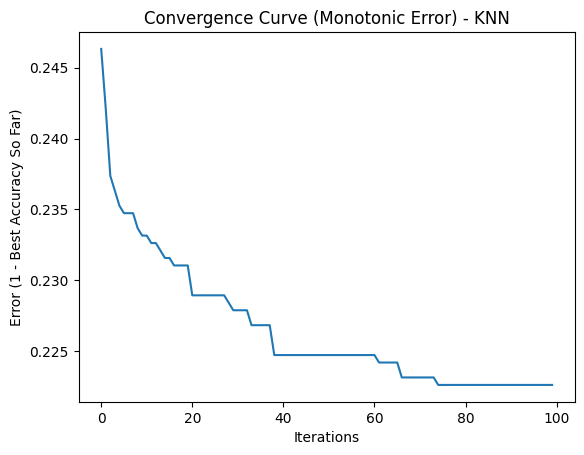

Selected Features: [1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14, 15, 16, 19, 21]
Without FS: {'Accuracy': 0.7088607594936709, 'Precision': 0.39285714285714285, 'Recall': 0.1746031746031746, 'F1': 0.24175824175824176}
With FS: {'Accuracy': 0.6962025316455697, 'Precision': 0.3548387096774194, 'Recall': 0.1746031746031746, 'F1': 0.23404255319148937}

===== Running ACO for Naive Bayes =====


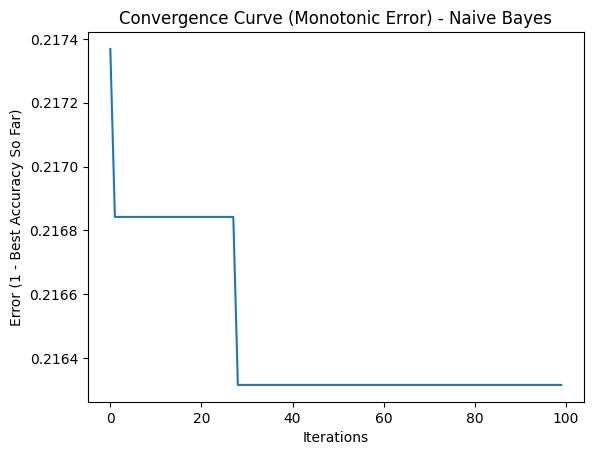

Selected Features: [0, 1, 3, 4, 6, 7, 10, 11, 12, 13, 14, 15, 16, 17, 18, 20, 21]
Without FS: {'Accuracy': 0.7341772151898734, 'Precision': 0.5, 'Recall': 0.2857142857142857, 'F1': 0.36363636363636365}
With FS: {'Accuracy': 0.7426160337552743, 'Precision': 0.5294117647058824, 'Recall': 0.2857142857142857, 'F1': 0.3711340206185567}

===== Running ACO for QDA =====


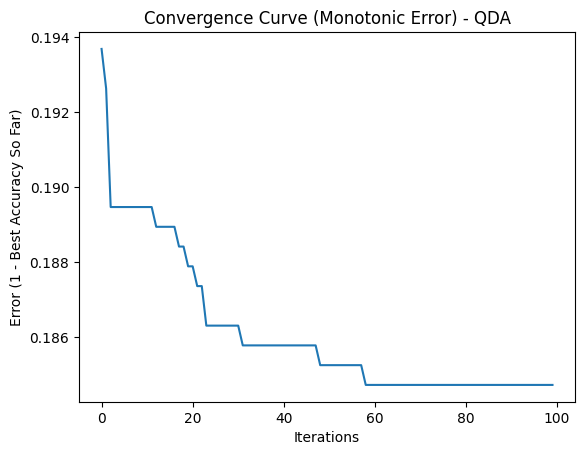

Selected Features: [0, 1, 2, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 16, 17, 18, 19, 20, 21]
Without FS: {'Accuracy': 0.7510548523206751, 'Precision': 0.5555555555555556, 'Recall': 0.31746031746031744, 'F1': 0.40404040404040403}
With FS: {'Accuracy': 0.7383966244725738, 'Precision': 0.5172413793103449, 'Recall': 0.23809523809523808, 'F1': 0.32608695652173914}

===== Running ACO for Random Forest =====


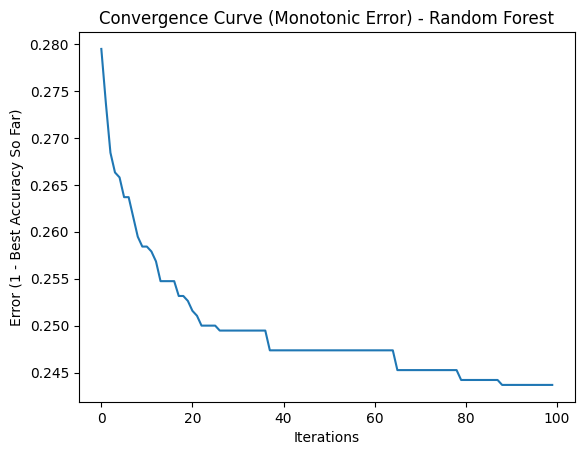

Selected Features: [1, 2, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17, 18, 19, 20, 21]
Without FS: {'Accuracy': 0.6075949367088608, 'Precision': 0.32954545454545453, 'Recall': 0.4603174603174603, 'F1': 0.3841059602649007}
With FS: {'Accuracy': 0.7046413502109705, 'Precision': 0.4492753623188406, 'Recall': 0.49206349206349204, 'F1': 0.4696969696969697}

===== FINAL RESULT TABLE =====
           Model  Accuracy (No FS)  Accuracy (With FS)  Precision    Recall  \
0            KNN          0.708861            0.696203   0.354839  0.174603   
1    Naive Bayes          0.734177            0.742616   0.529412  0.285714   
2            QDA          0.751055            0.738397   0.517241  0.238095   
3  Random Forest          0.607595            0.704641   0.449275  0.492063   

         F1  
0  0.234043  
1  0.371134  
2  0.326087  
3  0.469697  


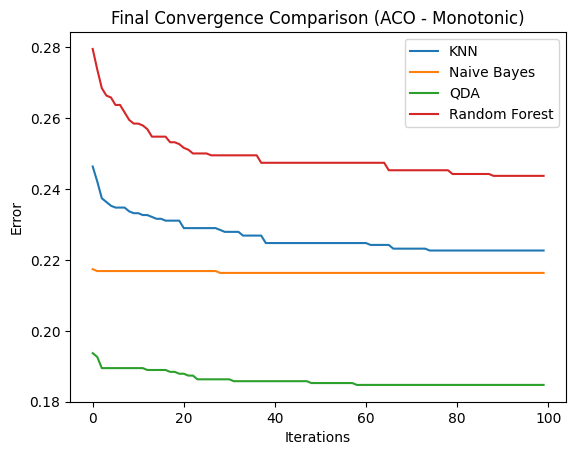


  Avg Execution Time : 384.2399 s
  Avg Memory Used    : 0.8408 MB


In [ ]:
# =========================
# FINAL WRAPPER ACO (MONOTONIC CONVERGENCE) - KC1
# =========================

import numpy as np
import pandas as pd
import random
import time
import tracemalloc
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier

# =========================
# LOAD DATA
# =========================
path = "/content/drive/MyDrive/DATASETS/csv_result-KC1.csv"
df = pd.read_csv(path)

df = df.drop(columns=['name'], errors='ignore')

target_col = df.columns[-1]

X = df.drop(columns=[target_col])
y = df[target_col].map({'N': 0, 'Y': 1})

# =========================
# SPLIT (NO DATA LEAKAGE)
# =========================
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# =========================
# MODELS
# =========================
models = {
    "KNN": KNeighborsClassifier(n_jobs=-1),
    "Naive Bayes": GaussianNB(),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1),
    "Random Forest": RandomForestClassifier(
        n_estimators=5,
        max_depth=5,
        n_jobs=-1,
        class_weight='balanced'
    )
}

# =========================
# ACO PARAMETERS
# =========================
NUM_ANTS = 10
ITERATIONS = 100
REPEATS = 10

EVAPORATION = 0.3
num_features = X_train.shape[1]

# =========================
# FITNESS (penalized)
# =========================
fitness_cache = {}

def fitness(solution, model):
    key = tuple(solution)

    if key in fitness_cache:
        return fitness_cache[key]

    if sum(solution) < 3:
        return 0

    selected = [i for i in range(len(solution)) if solution[i] == 1]

    X_tr = X_train[:, selected]
    X_v = X_val[:, selected]

    model.fit(X_tr, y_train)
    pred = model.predict(X_v)

    acc = accuracy_score(y_val, pred)

    feature_ratio = sum(solution) / num_features
    score = acc - 0.3 * feature_ratio

    fitness_cache[key] = score
    return score

# =========================
# CONSTRUCT SOLUTION
# =========================
def construct_solution(pheromone):
    solution = []

    for i in range(num_features):
        prob = pheromone[i] / (1 + pheromone[i])
        solution.append(1 if random.random() < prob else 0)

    return np.array(solution)

# =========================
# RUN ACO
# =========================
results = []
Total_time = []
Total_memory = []
model_curves = {}

for model_name, model in models.items():

    print(f"\n===== Running ACO for {model_name} =====")

    all_curves = []

    tracemalloc.start()
    start_time = time.time()

    best_global = None
    best_score = -1

    for r in range(REPEATS):

        pheromone = np.ones(num_features)
        curve = []
        best_so_far = 0   # 🔥 key for monotonic graph

        for it in range(ITERATIONS):

            solutions = []
            scores = []
            acc_list = []

            for ant in range(NUM_ANTS):
                sol = construct_solution(pheromone)

                selected = [i for i in range(len(sol)) if sol[i] == 1]

                if len(selected) < 3:
                    acc = 0
                else:
                    model.fit(X_train[:, selected], y_train)
                    pred = model.predict(X_val[:, selected])
                    acc = accuracy_score(y_val, pred)

                acc_list.append(acc)

                feature_ratio = sum(sol) / num_features
                score = acc - 0.3 * feature_ratio

                solutions.append(sol)
                scores.append(score)

            # pheromone update
            pheromone = (1 - EVAPORATION) * pheromone
            for sol, score in zip(solutions, scores):
                pheromone += score * sol

            # 🔥 MONOTONIC CONVERGENCE
            best_acc = max(acc_list)
            best_so_far = max(best_so_far, best_acc)

            curve.append(1 - best_so_far)   # error

        all_curves.append(curve)

        best_idx = np.argmax(scores)
        if scores[best_idx] > best_score:
            best_score = scores[best_idx]
            best_global = solutions[best_idx]

    # Time & Memory
    end_time = time.time()
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    Total_time.append(end_time - start_time)
    Total_memory.append(peak / 10**6)

    # Mean curve
    mean_curve = np.mean(all_curves, axis=0)
    model_curves[model_name] = mean_curve

    plt.figure()
    plt.plot(mean_curve)
    plt.title(f"Convergence Curve (Monotonic Error) - {model_name}")
    plt.xlabel("Iterations")
    plt.ylabel("Error (1 - Best Accuracy So Far)")
    plt.show()

    # Selected features
    selected_features = [i for i in range(len(best_global)) if best_global[i] == 1]
    if len(selected_features) == 0:
        selected_features = list(range(num_features))

    print("Selected Features:", selected_features)

    # =========================
    # FINAL EVALUATION
    # =========================
    def evaluate(model, X_tr, X_te):
        model.fit(X_tr, y_train_full)
        pred = model.predict(X_te)

        return {
            "Accuracy": accuracy_score(y_test, pred),
            "Precision": precision_score(y_test, pred, zero_division=0),
            "Recall": recall_score(y_test, pred, zero_division=0),
            "F1": f1_score(y_test, pred, zero_division=0)
        }

    res1 = evaluate(model, scaler.transform(X_train_full), X_test)

    X_train_fs = scaler.transform(X_train_full)[:, selected_features]
    X_test_fs = X_test[:, selected_features]

    res2 = evaluate(model, X_train_fs, X_test_fs)

    print("Without FS:", res1)
    print("With FS:", res2)

    results.append([
        model_name,
        res1["Accuracy"], res2["Accuracy"],
        res2["Precision"], res2["Recall"], res2["F1"]
    ])

# =========================
# FINAL TABLE
# =========================
final_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy (No FS)", "Accuracy (With FS)",
    "Precision", "Recall", "F1"
])

print("\n===== FINAL RESULT TABLE =====")
print(final_df)

# =========================
# FINAL CONVERGENCE GRAPH
# =========================
plt.figure()

for model_name, curve in model_curves.items():
    plt.plot(curve, label=model_name)

plt.title("Final Convergence Comparison (ACO - Monotonic)")
plt.xlabel("Iterations")
plt.ylabel("Error")
plt.legend()
plt.show()

# =========================
# TIME & MEMORY
# =========================
print(f"\n  Avg Execution Time : {np.mean(Total_time):.4f} s")
print(f"  Avg Memory Used    : {np.mean(Total_memory):.4f} MB")


===== Running ACO for KNN =====


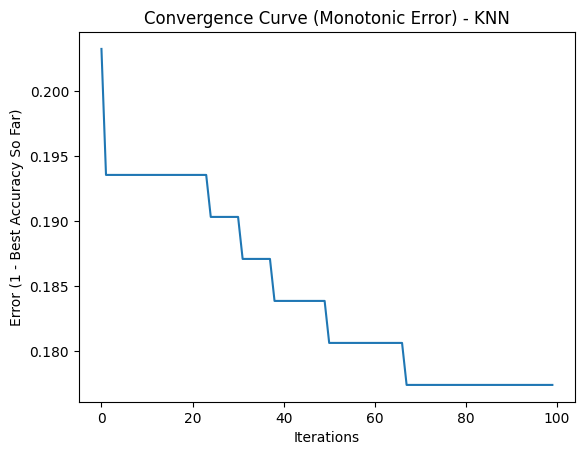

Selected Features: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 14, 16, 17, 18, 19, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]
Without FS: {'Accuracy': 0.8205128205128205, 'Precision': 0.5, 'Recall': 0.14285714285714285, 'F1': 0.2222222222222222}
With FS: {'Accuracy': 0.8461538461538461, 'Precision': 0.6666666666666666, 'Recall': 0.2857142857142857, 'F1': 0.4}

===== Running ACO for Naive Bayes =====


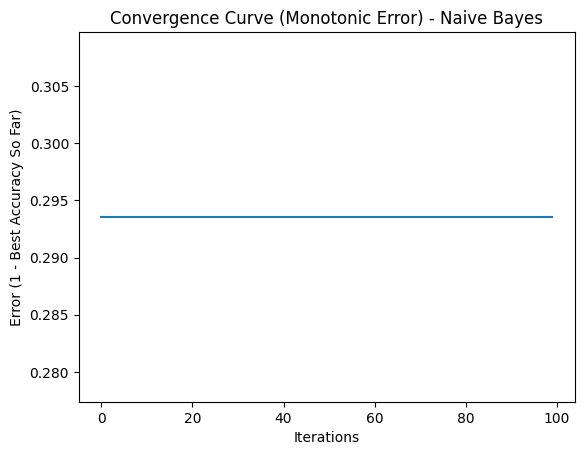

Selected Features: [0, 1, 2, 4, 5, 6, 7, 9, 10, 11, 12, 13, 14, 15, 17, 19, 20, 21, 24, 25, 26, 27, 28, 29, 30, 31, 33, 34, 35, 36, 37, 38, 39]
Without FS: {'Accuracy': 0.8205128205128205, 'Precision': 0.5, 'Recall': 0.42857142857142855, 'F1': 0.46153846153846156}
With FS: {'Accuracy': 0.8205128205128205, 'Precision': 0.5, 'Recall': 0.42857142857142855, 'F1': 0.46153846153846156}

===== Running ACO for QDA =====


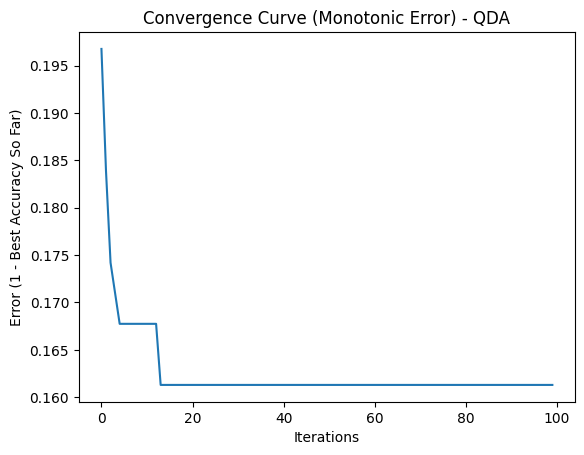

Selected Features: [0, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 23, 24, 25, 26, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]
Without FS: {'Accuracy': 0.8461538461538461, 'Precision': 1.0, 'Recall': 0.14285714285714285, 'F1': 0.25}
With FS: {'Accuracy': 0.8461538461538461, 'Precision': 1.0, 'Recall': 0.14285714285714285, 'F1': 0.25}

===== Running ACO for Random Forest =====


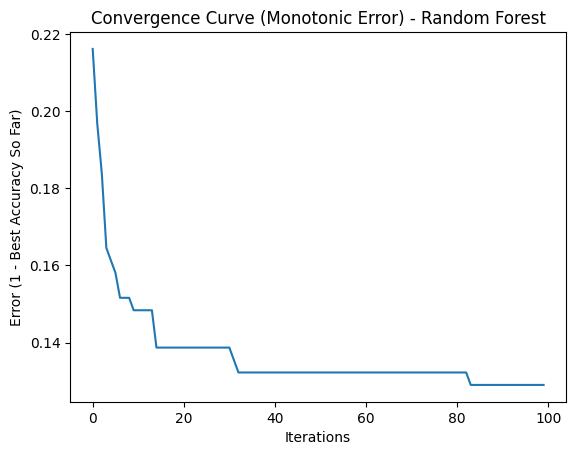

Selected Features: [0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 13, 14, 16, 17, 19, 20, 21, 22, 23, 24, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]
Without FS: {'Accuracy': 0.8717948717948718, 'Precision': 1.0, 'Recall': 0.2857142857142857, 'F1': 0.4444444444444444}
With FS: {'Accuracy': 0.7435897435897436, 'Precision': 0.2857142857142857, 'Recall': 0.2857142857142857, 'F1': 0.2857142857142857}

===== FINAL RESULT TABLE =====
           Model  Accuracy (No FS)  Accuracy (With FS)  Precision    Recall  \
0            KNN          0.820513            0.846154   0.666667  0.285714   
1    Naive Bayes          0.820513            0.820513   0.500000  0.428571   
2            QDA          0.846154            0.846154   1.000000  0.142857   
3  Random Forest          0.871795            0.743590   0.285714  0.285714   

         F1  
0  0.400000  
1  0.461538  
2  0.250000  
3  0.285714  


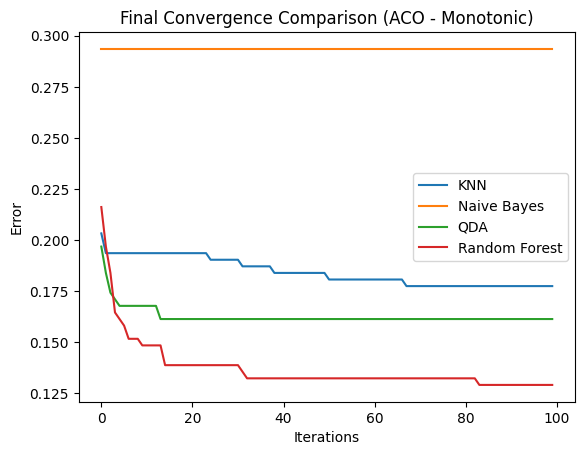


  Avg Execution Time : 407.5398 s
  Avg Memory Used    : 0.5825 MB


In [ ]:
# =========================
# FINAL WRAPPER ACO (MONOTONIC CONVERGENCE) - KC3
# =========================

import numpy as np
import pandas as pd
import random
import time
import tracemalloc
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier

# =========================
# LOAD DATA
# =========================
path = "/content/drive/MyDrive/DATASETS/csv_result-KC3.csv"
df = pd.read_csv(path)

df = df.drop(columns=['name'], errors='ignore')

target_col = df.columns[-1]

X = df.drop(columns=[target_col])
y = df[target_col].map({'N': 0, 'Y': 1})

# =========================
# SPLIT (NO DATA LEAKAGE)
# =========================
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# =========================
# MODELS
# =========================
models = {
    "KNN": KNeighborsClassifier(n_jobs=-1),
    "Naive Bayes": GaussianNB(),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1),
    "Random Forest": RandomForestClassifier(
        n_estimators=5,
        max_depth=5,
        n_jobs=-1,
        class_weight='balanced'
    )
}

# =========================
# ACO PARAMETERS
# =========================
NUM_ANTS = 10
ITERATIONS = 100
REPEATS = 10

EVAPORATION = 0.3
num_features = X_train.shape[1]

# =========================
# FITNESS (penalized)
# =========================
fitness_cache = {}

def fitness(solution, model):
    key = tuple(solution)

    if key in fitness_cache:
        return fitness_cache[key]

    if sum(solution) < 3:
        return 0

    selected = [i for i in range(len(solution)) if solution[i] == 1]

    X_tr = X_train[:, selected]
    X_v = X_val[:, selected]

    model.fit(X_tr, y_train)
    pred = model.predict(X_v)

    acc = accuracy_score(y_val, pred)

    feature_ratio = sum(solution) / num_features
    score = acc - 0.3 * feature_ratio

    fitness_cache[key] = score
    return score

# =========================
# CONSTRUCT SOLUTION
# =========================
def construct_solution(pheromone):
    solution = []

    for i in range(num_features):
        prob = pheromone[i] / (1 + pheromone[i])
        solution.append(1 if random.random() < prob else 0)

    return np.array(solution)

# =========================
# RUN ACO
# =========================
results = []
Total_time = []
Total_memory = []
model_curves = {}

for model_name, model in models.items():

    print(f"\n===== Running ACO for {model_name} =====")

    all_curves = []

    tracemalloc.start()
    start_time = time.time()

    best_global = None
    best_score = -1

    for r in range(REPEATS):

        pheromone = np.ones(num_features)
        curve = []
        best_so_far = 0   # 🔥 key for monotonic graph

        for it in range(ITERATIONS):

            solutions = []
            scores = []
            acc_list = []

            for ant in range(NUM_ANTS):
                sol = construct_solution(pheromone)

                selected = [i for i in range(len(sol)) if sol[i] == 1]

                if len(selected) < 3:
                    acc = 0
                else:
                    model.fit(X_train[:, selected], y_train)
                    pred = model.predict(X_val[:, selected])
                    acc = accuracy_score(y_val, pred)

                acc_list.append(acc)

                feature_ratio = sum(sol) / num_features
                score = acc - 0.3 * feature_ratio

                solutions.append(sol)
                scores.append(score)

            # pheromone update
            pheromone = (1 - EVAPORATION) * pheromone
            for sol, score in zip(solutions, scores):
                pheromone += score * sol

            # 🔥 MONOTONIC CONVERGENCE
            best_acc = max(acc_list)
            best_so_far = max(best_so_far, best_acc)

            curve.append(1 - best_so_far)   # error

        all_curves.append(curve)

        best_idx = np.argmax(scores)
        if scores[best_idx] > best_score:
            best_score = scores[best_idx]
            best_global = solutions[best_idx]

    # Time & Memory
    end_time = time.time()
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    Total_time.append(end_time - start_time)
    Total_memory.append(peak / 10**6)

    # Mean curve
    mean_curve = np.mean(all_curves, axis=0)
    model_curves[model_name] = mean_curve

    plt.figure()
    plt.plot(mean_curve)
    plt.title(f"Convergence Curve (Monotonic Error) - {model_name}")
    plt.xlabel("Iterations")
    plt.ylabel("Error (1 - Best Accuracy So Far)")
    plt.show()

    # Selected features
    selected_features = [i for i in range(len(best_global)) if best_global[i] == 1]
    if len(selected_features) == 0:
        selected_features = list(range(num_features))

    print("Selected Features:", selected_features)

    # =========================
    # FINAL EVALUATION
    # =========================
    def evaluate(model, X_tr, X_te):
        model.fit(X_tr, y_train_full)
        pred = model.predict(X_te)

        return {
            "Accuracy": accuracy_score(y_test, pred),
            "Precision": precision_score(y_test, pred, zero_division=0),
            "Recall": recall_score(y_test, pred, zero_division=0),
            "F1": f1_score(y_test, pred, zero_division=0)
        }

    res1 = evaluate(model, scaler.transform(X_train_full), X_test)

    X_train_fs = scaler.transform(X_train_full)[:, selected_features]
    X_test_fs = X_test[:, selected_features]

    res2 = evaluate(model, X_train_fs, X_test_fs)

    print("Without FS:", res1)
    print("With FS:", res2)

    results.append([
        model_name,
        res1["Accuracy"], res2["Accuracy"],
        res2["Precision"], res2["Recall"], res2["F1"]
    ])

# =========================
# FINAL TABLE
# =========================
final_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy (No FS)", "Accuracy (With FS)",
    "Precision", "Recall", "F1"
])

print("\n===== FINAL RESULT TABLE =====")
print(final_df)

# =========================
# FINAL CONVERGENCE GRAPH
# =========================
plt.figure()

for model_name, curve in model_curves.items():
    plt.plot(curve, label=model_name)

plt.title("Final Convergence Comparison (ACO - Monotonic)")
plt.xlabel("Iterations")
plt.ylabel("Error")
plt.legend()
plt.show()

# =========================
# TIME & MEMORY
# =========================
print(f"\n  Avg Execution Time : {np.mean(Total_time):.4f} s")
print(f"  Avg Memory Used    : {np.mean(Total_memory):.4f} MB")


===== Running ACO for KNN =====


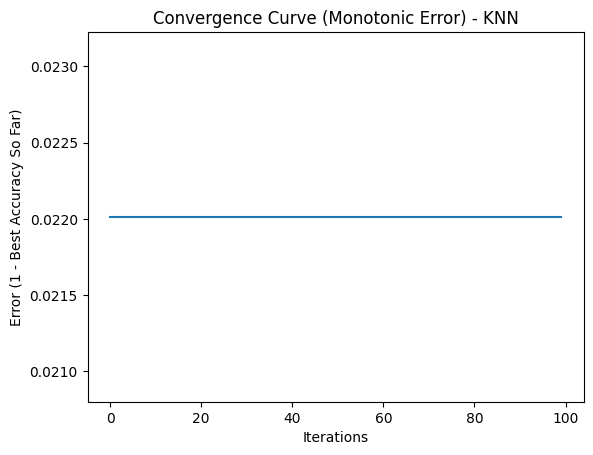

Selected Features: [0, 1, 2, 3, 4, 5, 6, 7, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 38]
Without FS: {'Accuracy': 0.9773869346733668, 'Precision': 0.5, 'Recall': 0.1111111111111111, 'F1': 0.18181818181818182}
With FS: {'Accuracy': 0.9773869346733668, 'Precision': 0.5, 'Recall': 0.1111111111111111, 'F1': 0.18181818181818182}

===== Running ACO for Naive Bayes =====


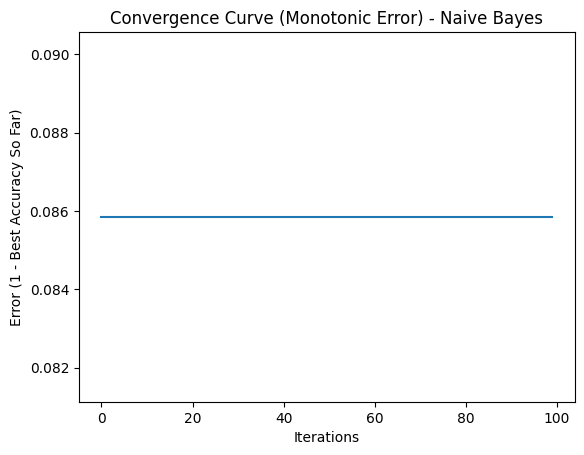

Selected Features: [1, 2, 3, 5, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 27, 28, 29, 30, 31, 32, 34, 35, 36, 37, 38]
Without FS: {'Accuracy': 0.9045226130653267, 'Precision': 0.06060606060606061, 'Recall': 0.2222222222222222, 'F1': 0.09523809523809523}
With FS: {'Accuracy': 0.9045226130653267, 'Precision': 0.03225806451612903, 'Recall': 0.1111111111111111, 'F1': 0.05}

===== Running ACO for QDA =====


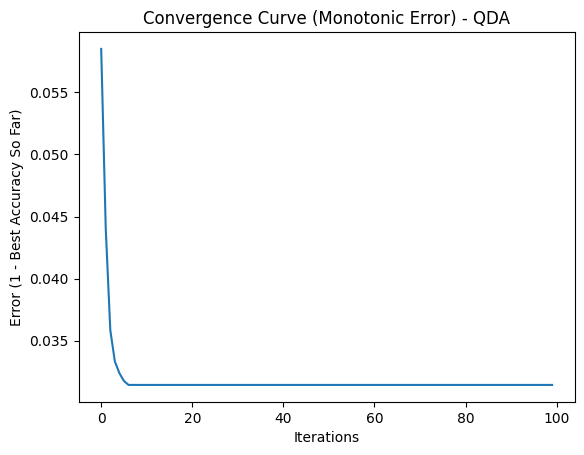

Selected Features: [0, 1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13, 14, 15, 17, 19, 20, 21, 22, 23, 24, 25, 27, 28, 29, 30, 32, 33, 34, 35, 36, 38]
Without FS: {'Accuracy': 0.949748743718593, 'Precision': 0.07692307692307693, 'Recall': 0.1111111111111111, 'F1': 0.09090909090909091}
With FS: {'Accuracy': 0.9447236180904522, 'Precision': 0.06666666666666667, 'Recall': 0.1111111111111111, 'F1': 0.08333333333333333}

===== Running ACO for Random Forest =====


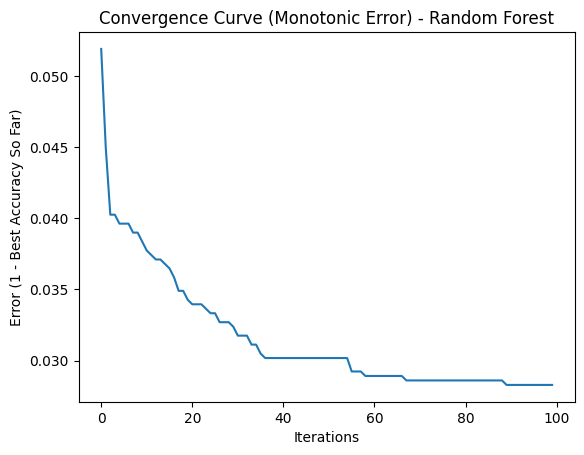

Selected Features: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 14, 15, 16, 17, 18, 19, 20, 22, 23, 24, 25, 26, 27, 28, 29, 31, 32, 33, 34, 35, 36, 37]
Without FS: {'Accuracy': 0.8894472361809045, 'Precision': 0.09302325581395349, 'Recall': 0.4444444444444444, 'F1': 0.15384615384615385}
With FS: {'Accuracy': 0.8844221105527639, 'Precision': 0.06976744186046512, 'Recall': 0.3333333333333333, 'F1': 0.11538461538461539}

===== FINAL RESULT TABLE =====
           Model  Accuracy (No FS)  Accuracy (With FS)  Precision    Recall  \
0            KNN          0.977387            0.977387   0.500000  0.111111   
1    Naive Bayes          0.904523            0.904523   0.032258  0.111111   
2            QDA          0.949749            0.944724   0.066667  0.111111   
3  Random Forest          0.889447            0.884422   0.069767  0.333333   

         F1  
0  0.181818  
1  0.050000  
2  0.083333  
3  0.115385  


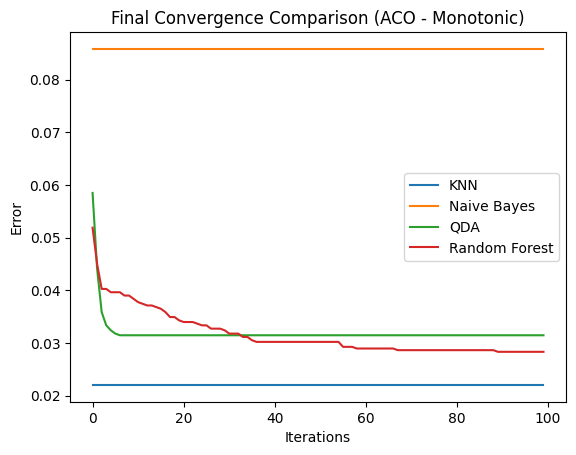


  Avg Execution Time : 464.8501 s
  Avg Memory Used    : 1.6137 MB


In [ ]:
# =========================
# FINAL WRAPPER ACO (MONOTONIC CONVERGENCE) - MC1
# =========================

import numpy as np
import pandas as pd
import random
import time
import tracemalloc
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier

# =========================
# LOAD DATA
# =========================
path = "/content/drive/MyDrive/DATASETS/csv_result-MC1.csv"
df = pd.read_csv(path)

df = df.drop(columns=['name'], errors='ignore')

target_col = df.columns[-1]

X = df.drop(columns=[target_col])
y = df[target_col].map({'N': 0, 'Y': 1})

# =========================
# SPLIT (NO DATA LEAKAGE)
# =========================
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# =========================
# MODELS
# =========================
models = {
    "KNN": KNeighborsClassifier(n_jobs=-1),
    "Naive Bayes": GaussianNB(),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1),
    "Random Forest": RandomForestClassifier(
        n_estimators=5,
        max_depth=5,
        n_jobs=-1,
        class_weight='balanced'
    )
}

# =========================
# ACO PARAMETERS
# =========================
NUM_ANTS = 10
ITERATIONS = 100
REPEATS = 10

EVAPORATION = 0.3
num_features = X_train.shape[1]

# =========================
# FITNESS (penalized)
# =========================
fitness_cache = {}

def fitness(solution, model):
    key = tuple(solution)

    if key in fitness_cache:
        return fitness_cache[key]

    if sum(solution) < 3:
        return 0

    selected = [i for i in range(len(solution)) if solution[i] == 1]

    X_tr = X_train[:, selected]
    X_v = X_val[:, selected]

    model.fit(X_tr, y_train)
    pred = model.predict(X_v)

    acc = accuracy_score(y_val, pred)

    feature_ratio = sum(solution) / num_features
    score = acc - 0.3 * feature_ratio

    fitness_cache[key] = score
    return score

# =========================
# CONSTRUCT SOLUTION
# =========================
def construct_solution(pheromone):
    solution = []

    for i in range(num_features):
        prob = pheromone[i] / (1 + pheromone[i])
        solution.append(1 if random.random() < prob else 0)

    return np.array(solution)

# =========================
# RUN ACO
# =========================
results = []
Total_time = []
Total_memory = []
model_curves = {}

for model_name, model in models.items():

    print(f"\n===== Running ACO for {model_name} =====")

    all_curves = []

    tracemalloc.start()
    start_time = time.time()

    best_global = None
    best_score = -1

    for r in range(REPEATS):

        pheromone = np.ones(num_features)
        curve = []
        best_so_far = 0   # 🔥 key for monotonic graph

        for it in range(ITERATIONS):

            solutions = []
            scores = []
            acc_list = []

            for ant in range(NUM_ANTS):
                sol = construct_solution(pheromone)

                selected = [i for i in range(len(sol)) if sol[i] == 1]

                if len(selected) < 3:
                    acc = 0
                else:
                    model.fit(X_train[:, selected], y_train)
                    pred = model.predict(X_val[:, selected])
                    acc = accuracy_score(y_val, pred)

                acc_list.append(acc)

                feature_ratio = sum(sol) / num_features
                score = acc - 0.3 * feature_ratio

                solutions.append(sol)
                scores.append(score)

            # pheromone update
            pheromone = (1 - EVAPORATION) * pheromone
            for sol, score in zip(solutions, scores):
                pheromone += score * sol

            # 🔥 MONOTONIC CONVERGENCE
            best_acc = max(acc_list)
            best_so_far = max(best_so_far, best_acc)

            curve.append(1 - best_so_far)   # error

        all_curves.append(curve)

        best_idx = np.argmax(scores)
        if scores[best_idx] > best_score:
            best_score = scores[best_idx]
            best_global = solutions[best_idx]

    # Time & Memory
    end_time = time.time()
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    Total_time.append(end_time - start_time)
    Total_memory.append(peak / 10**6)

    # Mean curve
    mean_curve = np.mean(all_curves, axis=0)
    model_curves[model_name] = mean_curve

    plt.figure()
    plt.plot(mean_curve)
    plt.title(f"Convergence Curve (Monotonic Error) - {model_name}")
    plt.xlabel("Iterations")
    plt.ylabel("Error (1 - Best Accuracy So Far)")
    plt.show()

    # Selected features
    selected_features = [i for i in range(len(best_global)) if best_global[i] == 1]
    if len(selected_features) == 0:
        selected_features = list(range(num_features))

    print("Selected Features:", selected_features)

    # =========================
    # FINAL EVALUATION
    # =========================
    def evaluate(model, X_tr, X_te):
        model.fit(X_tr, y_train_full)
        pred = model.predict(X_te)

        return {
            "Accuracy": accuracy_score(y_test, pred),
            "Precision": precision_score(y_test, pred, zero_division=0),
            "Recall": recall_score(y_test, pred, zero_division=0),
            "F1": f1_score(y_test, pred, zero_division=0)
        }

    res1 = evaluate(model, scaler.transform(X_train_full), X_test)

    X_train_fs = scaler.transform(X_train_full)[:, selected_features]
    X_test_fs = X_test[:, selected_features]

    res2 = evaluate(model, X_train_fs, X_test_fs)

    print("Without FS:", res1)
    print("With FS:", res2)

    results.append([
        model_name,
        res1["Accuracy"], res2["Accuracy"],
        res2["Precision"], res2["Recall"], res2["F1"]
    ])

# =========================
# FINAL TABLE
# =========================
final_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy (No FS)", "Accuracy (With FS)",
    "Precision", "Recall", "F1"
])

print("\n===== FINAL RESULT TABLE =====")
print(final_df)

# =========================
# FINAL CONVERGENCE GRAPH
# =========================
plt.figure()

for model_name, curve in model_curves.items():
    plt.plot(curve, label=model_name)

plt.title("Final Convergence Comparison (ACO - Monotonic)")
plt.xlabel("Iterations")
plt.ylabel("Error")
plt.legend()
plt.show()

# =========================
# TIME & MEMORY
# =========================
print(f"\n  Avg Execution Time : {np.mean(Total_time):.4f} s")
print(f"  Avg Memory Used    : {np.mean(Total_memory):.4f} MB")


===== Running ACO for KNN =====


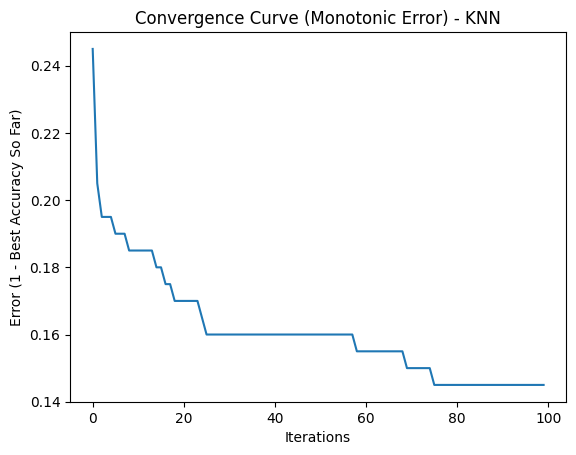

Selected Features: [1, 2, 3, 4, 5, 6, 7, 8, 9, 11, 12, 13, 14, 15, 16, 17, 19, 20, 21, 22, 23, 24, 25, 26, 27, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]
Without FS: {'Accuracy': 0.68, 'Precision': 0.6666666666666666, 'Recall': 0.2222222222222222, 'F1': 0.3333333333333333}
With FS: {'Accuracy': 0.68, 'Precision': 0.6, 'Recall': 0.3333333333333333, 'F1': 0.42857142857142855}

===== Running ACO for Naive Bayes =====


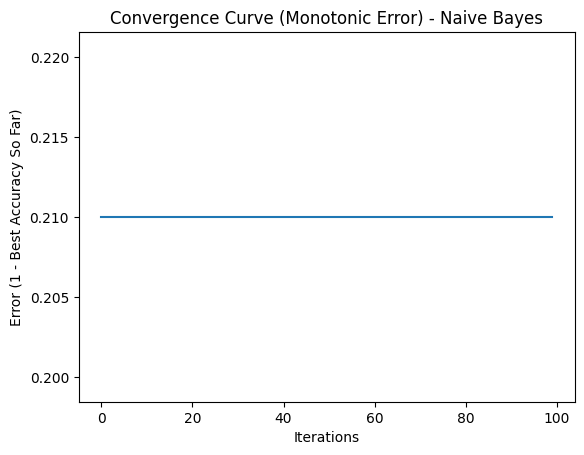

Selected Features: [0, 2, 3, 4, 5, 6, 8, 10, 12, 13, 14, 16, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]
Without FS: {'Accuracy': 0.68, 'Precision': 0.6666666666666666, 'Recall': 0.2222222222222222, 'F1': 0.3333333333333333}
With FS: {'Accuracy': 0.68, 'Precision': 0.6666666666666666, 'Recall': 0.2222222222222222, 'F1': 0.3333333333333333}

===== Running ACO for QDA =====


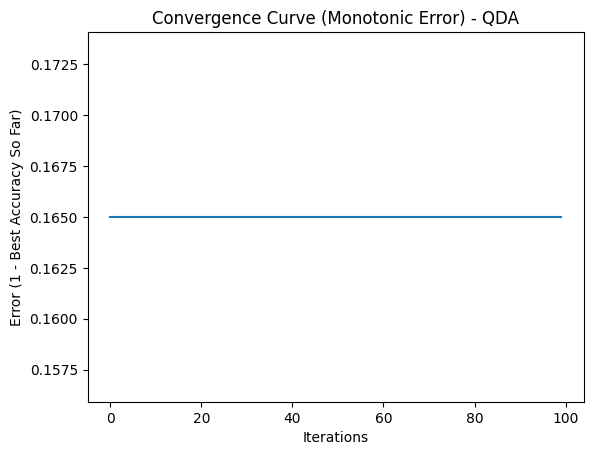

Selected Features: [0, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 23, 24, 25, 26, 28, 29, 30, 31, 32, 33, 34, 36, 37, 38, 39]
Without FS: {'Accuracy': 0.64, 'Precision': 0.5, 'Recall': 0.1111111111111111, 'F1': 0.18181818181818182}
With FS: {'Accuracy': 0.6, 'Precision': 0.4, 'Recall': 0.2222222222222222, 'F1': 0.2857142857142857}

===== Running ACO for Random Forest =====


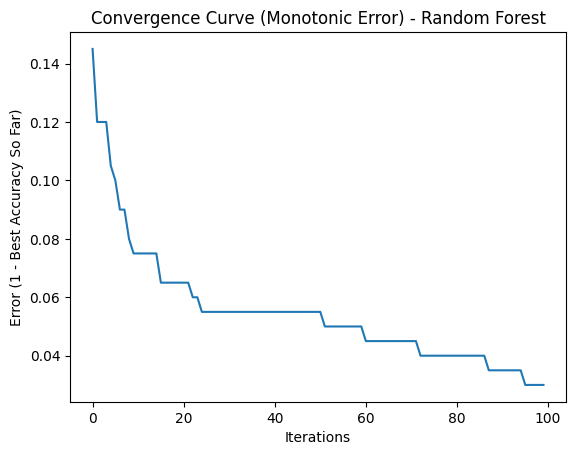

Selected Features: [0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 12, 13, 14, 15, 16, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]
Without FS: {'Accuracy': 0.56, 'Precision': 0.375, 'Recall': 0.3333333333333333, 'F1': 0.35294117647058826}
With FS: {'Accuracy': 0.6, 'Precision': 0.4, 'Recall': 0.2222222222222222, 'F1': 0.2857142857142857}

===== FINAL RESULT TABLE =====
           Model  Accuracy (No FS)  Accuracy (With FS)  Precision    Recall  \
0            KNN              0.68                0.68   0.600000  0.333333   
1    Naive Bayes              0.68                0.68   0.666667  0.222222   
2            QDA              0.64                0.60   0.400000  0.222222   
3  Random Forest              0.56                0.60   0.400000  0.222222   

         F1  
0  0.428571  
1  0.333333  
2  0.285714  
3  0.285714  


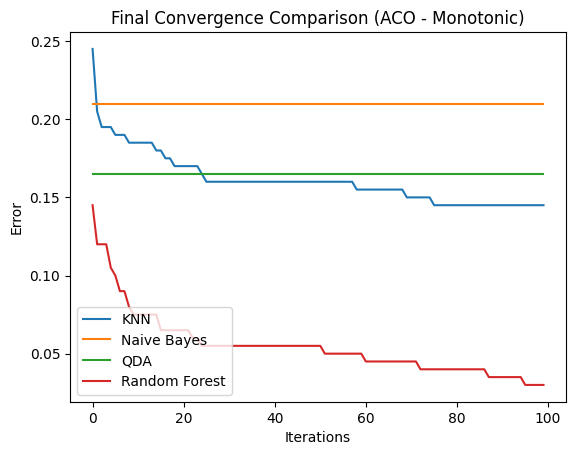


  Avg Execution Time : 403.8464 s
  Avg Memory Used    : 0.4850 MB


In [ ]:
# =========================
# FINAL WRAPPER ACO (MONOTONIC CONVERGENCE) - MC1
# =========================

import numpy as np
import pandas as pd
import random
import time
import tracemalloc
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier

# =========================
# LOAD DATA
# =========================
path = "/content/drive/MyDrive/DATASETS/csv_result-MC2.csv"
df = pd.read_csv(path)

df = df.drop(columns=['name'], errors='ignore')

target_col = df.columns[-1]

X = df.drop(columns=[target_col])
y = df[target_col].map({'N': 0, 'Y': 1})

# =========================
# SPLIT (NO DATA LEAKAGE)
# =========================
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# =========================
# MODELS
# =========================
models = {
    "KNN": KNeighborsClassifier(n_jobs=-1),
    "Naive Bayes": GaussianNB(),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1),
    "Random Forest": RandomForestClassifier(
        n_estimators=5,
        max_depth=5,
        n_jobs=-1,
        class_weight='balanced'
    )
}

# =========================
# ACO PARAMETERS
# =========================
NUM_ANTS = 10
ITERATIONS = 100
REPEATS = 10

EVAPORATION = 0.3
num_features = X_train.shape[1]

# =========================
# FITNESS (penalized)
# =========================
fitness_cache = {}

def fitness(solution, model):
    key = tuple(solution)

    if key in fitness_cache:
        return fitness_cache[key]

    if sum(solution) < 3:
        return 0

    selected = [i for i in range(len(solution)) if solution[i] == 1]

    X_tr = X_train[:, selected]
    X_v = X_val[:, selected]

    model.fit(X_tr, y_train)
    pred = model.predict(X_v)

    acc = accuracy_score(y_val, pred)

    feature_ratio = sum(solution) / num_features
    score = acc - 0.3 * feature_ratio

    fitness_cache[key] = score
    return score

# =========================
# CONSTRUCT SOLUTION
# =========================
def construct_solution(pheromone):
    solution = []

    for i in range(num_features):
        prob = pheromone[i] / (1 + pheromone[i])
        solution.append(1 if random.random() < prob else 0)

    return np.array(solution)

# =========================
# RUN ACO
# =========================
results = []
Total_time = []
Total_memory = []
model_curves = {}

for model_name, model in models.items():

    print(f"\n===== Running ACO for {model_name} =====")

    all_curves = []

    tracemalloc.start()
    start_time = time.time()

    best_global = None
    best_score = -1

    for r in range(REPEATS):

        pheromone = np.ones(num_features)
        curve = []
        best_so_far = 0   # 🔥 key for monotonic graph

        for it in range(ITERATIONS):

            solutions = []
            scores = []
            acc_list = []

            for ant in range(NUM_ANTS):
                sol = construct_solution(pheromone)

                selected = [i for i in range(len(sol)) if sol[i] == 1]

                if len(selected) < 3:
                    acc = 0
                else:
                    model.fit(X_train[:, selected], y_train)
                    pred = model.predict(X_val[:, selected])
                    acc = accuracy_score(y_val, pred)

                acc_list.append(acc)

                feature_ratio = sum(sol) / num_features
                score = acc - 0.3 * feature_ratio

                solutions.append(sol)
                scores.append(score)

            # pheromone update
            pheromone = (1 - EVAPORATION) * pheromone
            for sol, score in zip(solutions, scores):
                pheromone += score * sol

            # 🔥 MONOTONIC CONVERGENCE
            best_acc = max(acc_list)
            best_so_far = max(best_so_far, best_acc)

            curve.append(1 - best_so_far)   # error

        all_curves.append(curve)

        best_idx = np.argmax(scores)
        if scores[best_idx] > best_score:
            best_score = scores[best_idx]
            best_global = solutions[best_idx]

    # Time & Memory
    end_time = time.time()
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    Total_time.append(end_time - start_time)
    Total_memory.append(peak / 10**6)

    # Mean curve
    mean_curve = np.mean(all_curves, axis=0)
    model_curves[model_name] = mean_curve

    plt.figure()
    plt.plot(mean_curve)
    plt.title(f"Convergence Curve (Monotonic Error) - {model_name}")
    plt.xlabel("Iterations")
    plt.ylabel("Error (1 - Best Accuracy So Far)")
    plt.show()

    # Selected features
    selected_features = [i for i in range(len(best_global)) if best_global[i] == 1]
    if len(selected_features) == 0:
        selected_features = list(range(num_features))

    print("Selected Features:", selected_features)

    # =========================
    # FINAL EVALUATION
    # =========================
    def evaluate(model, X_tr, X_te):
        model.fit(X_tr, y_train_full)
        pred = model.predict(X_te)

        return {
            "Accuracy": accuracy_score(y_test, pred),
            "Precision": precision_score(y_test, pred, zero_division=0),
            "Recall": recall_score(y_test, pred, zero_division=0),
            "F1": f1_score(y_test, pred, zero_division=0)
        }

    res1 = evaluate(model, scaler.transform(X_train_full), X_test)

    X_train_fs = scaler.transform(X_train_full)[:, selected_features]
    X_test_fs = X_test[:, selected_features]

    res2 = evaluate(model, X_train_fs, X_test_fs)

    print("Without FS:", res1)
    print("With FS:", res2)

    results.append([
        model_name,
        res1["Accuracy"], res2["Accuracy"],
        res2["Precision"], res2["Recall"], res2["F1"]
    ])

# =========================
# FINAL TABLE
# =========================
final_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy (No FS)", "Accuracy (With FS)",
    "Precision", "Recall", "F1"
])

print("\n===== FINAL RESULT TABLE =====")
print(final_df)

# =========================
# FINAL CONVERGENCE GRAPH
# =========================
plt.figure()

for model_name, curve in model_curves.items():
    plt.plot(curve, label=model_name)

plt.title("Final Convergence Comparison (ACO - Monotonic)")
plt.xlabel("Iterations")
plt.ylabel("Error")
plt.legend()
plt.show()

# =========================
# TIME & MEMORY
# =========================
print(f"\n  Avg Execution Time : {np.mean(Total_time):.4f} s")
print(f"  Avg Memory Used    : {np.mean(Total_memory):.4f} MB")


===== Running ACO for KNN =====


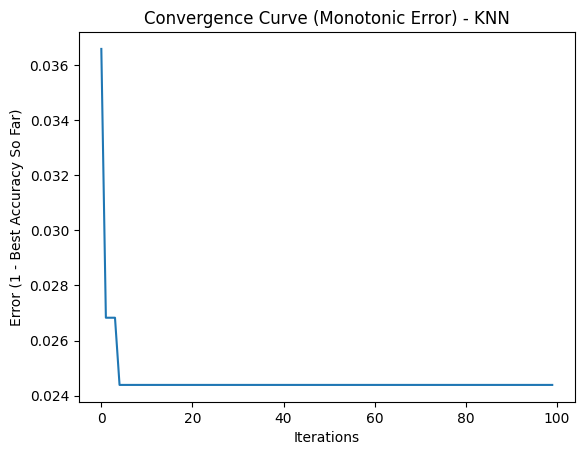

Selected Features: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 14, 15, 16, 17, 19, 20, 21, 23, 24, 25, 27, 28, 29, 30, 31, 32, 34, 35, 36, 37]
Without FS: {'Accuracy': 0.8235294117647058, 'Precision': 0.0, 'Recall': 0.0, 'F1': 0.0}
With FS: {'Accuracy': 0.8627450980392157, 'Precision': 0.3333333333333333, 'Recall': 0.4, 'F1': 0.36363636363636365}

===== Running ACO for Naive Bayes =====


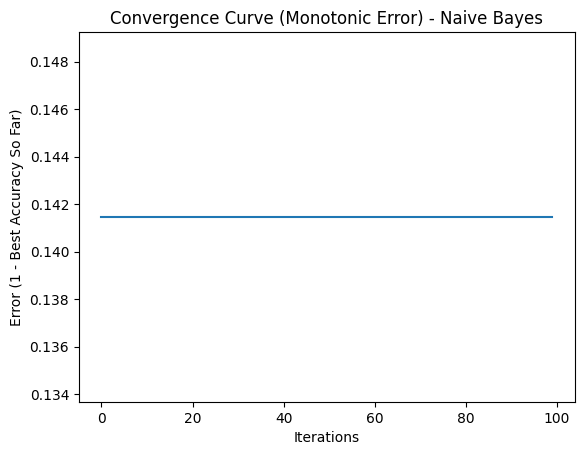

Selected Features: [0, 1, 2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 25, 26, 27, 28, 29, 30, 31, 32, 33, 35, 37]
Without FS: {'Accuracy': 0.7254901960784313, 'Precision': 0.2, 'Recall': 0.6, 'F1': 0.3}
With FS: {'Accuracy': 0.7450980392156863, 'Precision': 0.21428571428571427, 'Recall': 0.6, 'F1': 0.3157894736842105}

===== Running ACO for QDA =====


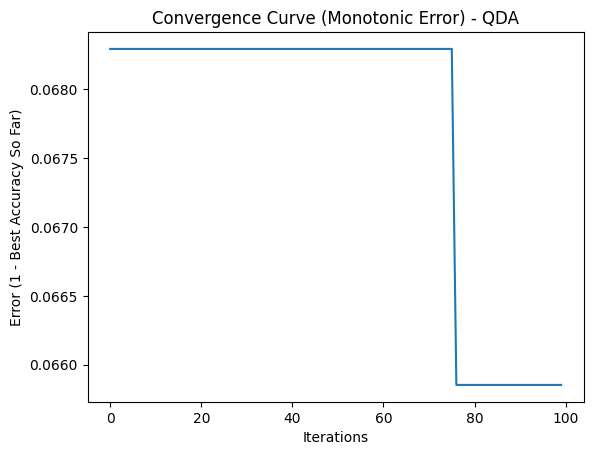

Selected Features: [0, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15, 16, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 33, 34, 35, 36, 37]
Without FS: {'Accuracy': 0.8823529411764706, 'Precision': 0.0, 'Recall': 0.0, 'F1': 0.0}
With FS: {'Accuracy': 0.8823529411764706, 'Precision': 0.0, 'Recall': 0.0, 'F1': 0.0}

===== Running ACO for Random Forest =====


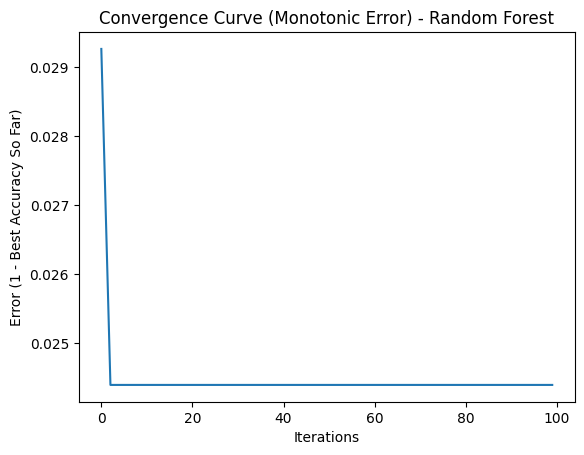

Selected Features: [1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 34, 35, 36, 37]
Without FS: {'Accuracy': 0.8235294117647058, 'Precision': 0.0, 'Recall': 0.0, 'F1': 0.0}
With FS: {'Accuracy': 0.7843137254901961, 'Precision': 0.125, 'Recall': 0.2, 'F1': 0.15384615384615385}

===== FINAL RESULT TABLE =====
           Model  Accuracy (No FS)  Accuracy (With FS)  Precision  Recall  \
0            KNN          0.823529            0.862745   0.333333     0.4   
1    Naive Bayes          0.725490            0.745098   0.214286     0.6   
2            QDA          0.882353            0.882353   0.000000     0.0   
3  Random Forest          0.823529            0.784314   0.125000     0.2   

         F1  
0  0.363636  
1  0.315789  
2  0.000000  
3  0.153846  


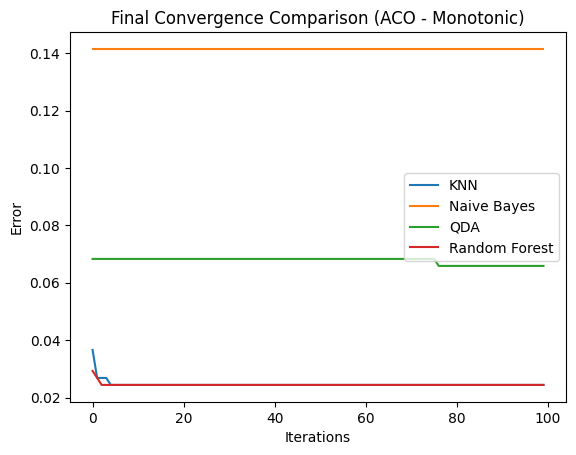


  Avg Execution Time : 398.5064 s
  Avg Memory Used    : 0.5415 MB


In [ ]:
# =========================
# FINAL WRAPPER ACO (MONOTONIC CONVERGENCE) - MC1
# =========================

import numpy as np
import pandas as pd
import random
import time
import tracemalloc
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier

# =========================
# LOAD DATA
# =========================
path = "/content/drive/MyDrive/DATASETS/csv_result-MW1.csv"
df = pd.read_csv(path)

df = df.drop(columns=['name'], errors='ignore')

target_col = df.columns[-1]

X = df.drop(columns=[target_col])
y = df[target_col].map({'N': 0, 'Y': 1})

# =========================
# SPLIT (NO DATA LEAKAGE)
# =========================
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# =========================
# MODELS
# =========================
models = {
    "KNN": KNeighborsClassifier(n_jobs=-1),
    "Naive Bayes": GaussianNB(),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1),
    "Random Forest": RandomForestClassifier(
        n_estimators=5,
        max_depth=5,
        n_jobs=-1,
        class_weight='balanced'
    )
}

# =========================
# ACO PARAMETERS
# =========================
NUM_ANTS = 10
ITERATIONS = 100
REPEATS = 10

EVAPORATION = 0.3
num_features = X_train.shape[1]

# =========================
# FITNESS (penalized)
# =========================
fitness_cache = {}

def fitness(solution, model):
    key = tuple(solution)

    if key in fitness_cache:
        return fitness_cache[key]

    if sum(solution) < 3:
        return 0

    selected = [i for i in range(len(solution)) if solution[i] == 1]

    X_tr = X_train[:, selected]
    X_v = X_val[:, selected]

    model.fit(X_tr, y_train)
    pred = model.predict(X_v)

    acc = accuracy_score(y_val, pred)

    feature_ratio = sum(solution) / num_features
    score = acc - 0.3 * feature_ratio

    fitness_cache[key] = score
    return score

# =========================
# CONSTRUCT SOLUTION
# =========================
def construct_solution(pheromone):
    solution = []

    for i in range(num_features):
        prob = pheromone[i] / (1 + pheromone[i])
        solution.append(1 if random.random() < prob else 0)

    return np.array(solution)

# =========================
# RUN ACO
# =========================
results = []
Total_time = []
Total_memory = []
model_curves = {}

for model_name, model in models.items():

    print(f"\n===== Running ACO for {model_name} =====")

    all_curves = []

    tracemalloc.start()
    start_time = time.time()

    best_global = None
    best_score = -1

    for r in range(REPEATS):

        pheromone = np.ones(num_features)
        curve = []
        best_so_far = 0   # 🔥 key for monotonic graph

        for it in range(ITERATIONS):

            solutions = []
            scores = []
            acc_list = []

            for ant in range(NUM_ANTS):
                sol = construct_solution(pheromone)

                selected = [i for i in range(len(sol)) if sol[i] == 1]

                if len(selected) < 3:
                    acc = 0
                else:
                    model.fit(X_train[:, selected], y_train)
                    pred = model.predict(X_val[:, selected])
                    acc = accuracy_score(y_val, pred)

                acc_list.append(acc)

                feature_ratio = sum(sol) / num_features
                score = acc - 0.3 * feature_ratio

                solutions.append(sol)
                scores.append(score)

            # pheromone update
            pheromone = (1 - EVAPORATION) * pheromone
            for sol, score in zip(solutions, scores):
                pheromone += score * sol

            # 🔥 MONOTONIC CONVERGENCE
            best_acc = max(acc_list)
            best_so_far = max(best_so_far, best_acc)

            curve.append(1 - best_so_far)   # error

        all_curves.append(curve)

        best_idx = np.argmax(scores)
        if scores[best_idx] > best_score:
            best_score = scores[best_idx]
            best_global = solutions[best_idx]

    # Time & Memory
    end_time = time.time()
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    Total_time.append(end_time - start_time)
    Total_memory.append(peak / 10**6)

    # Mean curve
    mean_curve = np.mean(all_curves, axis=0)
    model_curves[model_name] = mean_curve

    plt.figure()
    plt.plot(mean_curve)
    plt.title(f"Convergence Curve (Monotonic Error) - {model_name}")
    plt.xlabel("Iterations")
    plt.ylabel("Error (1 - Best Accuracy So Far)")
    plt.show()

    # Selected features
    selected_features = [i for i in range(len(best_global)) if best_global[i] == 1]
    if len(selected_features) == 0:
        selected_features = list(range(num_features))

    print("Selected Features:", selected_features)

    # =========================
    # FINAL EVALUATION
    # =========================
    def evaluate(model, X_tr, X_te):
        model.fit(X_tr, y_train_full)
        pred = model.predict(X_te)

        return {
            "Accuracy": accuracy_score(y_test, pred),
            "Precision": precision_score(y_test, pred, zero_division=0),
            "Recall": recall_score(y_test, pred, zero_division=0),
            "F1": f1_score(y_test, pred, zero_division=0)
        }

    res1 = evaluate(model, scaler.transform(X_train_full), X_test)

    X_train_fs = scaler.transform(X_train_full)[:, selected_features]
    X_test_fs = X_test[:, selected_features]

    res2 = evaluate(model, X_train_fs, X_test_fs)

    print("Without FS:", res1)
    print("With FS:", res2)

    results.append([
        model_name,
        res1["Accuracy"], res2["Accuracy"],
        res2["Precision"], res2["Recall"], res2["F1"]
    ])

# =========================
# FINAL TABLE
# =========================
final_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy (No FS)", "Accuracy (With FS)",
    "Precision", "Recall", "F1"
])

print("\n===== FINAL RESULT TABLE =====")
print(final_df)

# =========================
# FINAL CONVERGENCE GRAPH
# =========================
plt.figure()

for model_name, curve in model_curves.items():
    plt.plot(curve, label=model_name)

plt.title("Final Convergence Comparison (ACO - Monotonic)")
plt.xlabel("Iterations")
plt.ylabel("Error")
plt.legend()
plt.show()

# =========================
# TIME & MEMORY
# =========================
print(f"\n  Avg Execution Time : {np.mean(Total_time):.4f} s")
print(f"  Avg Memory Used    : {np.mean(Total_memory):.4f} MB")


===== Running ACO for KNN =====


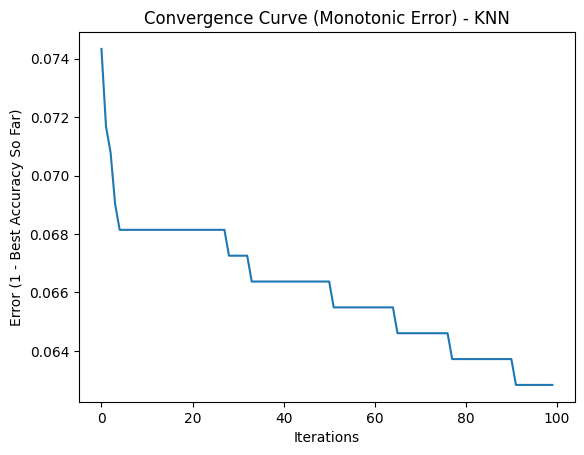

Selected Features: [0, 1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 17, 18, 21, 22, 23, 24, 25, 26, 28, 29, 30, 31, 32, 33, 35, 36, 37]
Without FS: {'Accuracy': 0.8865248226950354, 'Precision': 0.0, 'Recall': 0.0, 'F1': 0.0}
With FS: {'Accuracy': 0.8794326241134752, 'Precision': 0.0, 'Recall': 0.0, 'F1': 0.0}

===== Running ACO for Naive Bayes =====


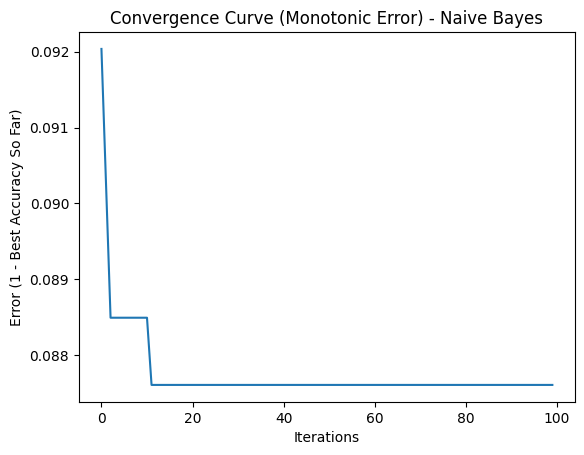

Selected Features: [0, 1, 2, 5, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37]
Without FS: {'Accuracy': 0.8865248226950354, 'Precision': 0.25, 'Recall': 0.16666666666666666, 'F1': 0.2}
With FS: {'Accuracy': 0.8865248226950354, 'Precision': 0.25, 'Recall': 0.16666666666666666, 'F1': 0.2}

===== Running ACO for QDA =====


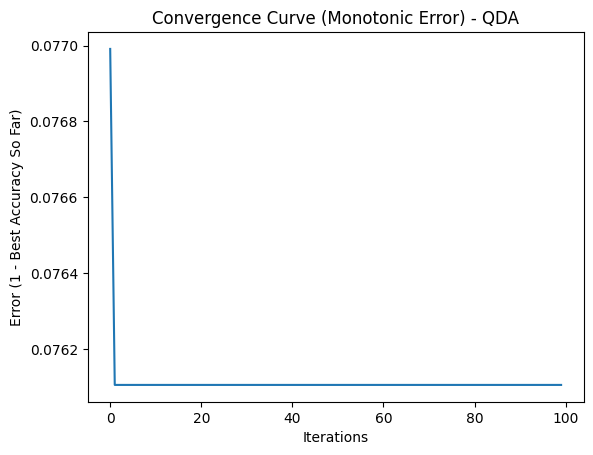

Selected Features: [0, 1, 2, 3, 5, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 23, 24, 25, 26, 27, 30, 31, 32, 33, 34, 35, 36, 37]
Without FS: {'Accuracy': 0.851063829787234, 'Precision': 0.15384615384615385, 'Recall': 0.16666666666666666, 'F1': 0.16}
With FS: {'Accuracy': 0.8794326241134752, 'Precision': 0.2222222222222222, 'Recall': 0.16666666666666666, 'F1': 0.19047619047619047}

===== Running ACO for Random Forest =====


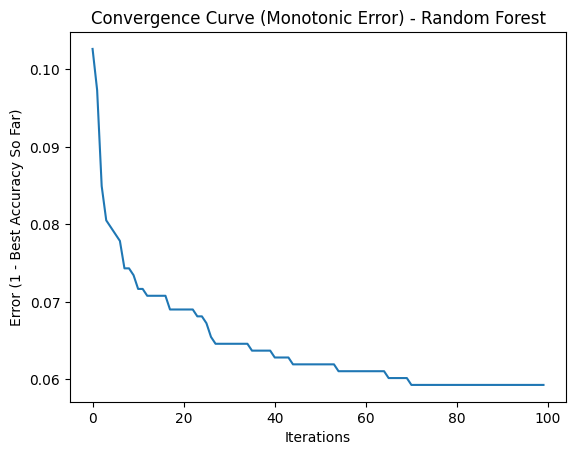

Selected Features: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 30, 31, 32, 33, 34, 35, 36, 37]
Without FS: {'Accuracy': 0.75177304964539, 'Precision': 0.10344827586206896, 'Recall': 0.25, 'F1': 0.14634146341463414}
With FS: {'Accuracy': 0.8085106382978723, 'Precision': 0.2222222222222222, 'Recall': 0.5, 'F1': 0.3076923076923077}

===== FINAL RESULT TABLE =====
           Model  Accuracy (No FS)  Accuracy (With FS)  Precision    Recall  \
0            KNN          0.886525            0.879433   0.000000  0.000000   
1    Naive Bayes          0.886525            0.886525   0.250000  0.166667   
2            QDA          0.851064            0.879433   0.222222  0.166667   
3  Random Forest          0.751773            0.808511   0.222222  0.500000   

         F1  
0  0.000000  
1  0.200000  
2  0.190476  
3  0.307692  


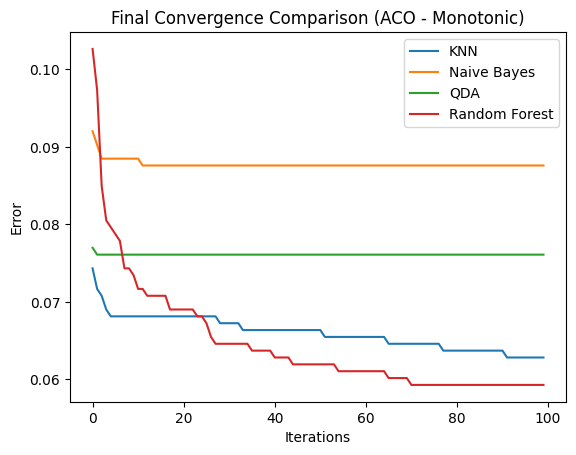


  Avg Execution Time : 436.7880 s
  Avg Memory Used    : 1.2881 MB


In [ ]:
# =========================
# FINAL WRAPPER ACO (MONOTONIC CONVERGENCE) - PC1
# =========================

import numpy as np
import pandas as pd
import random
import time
import tracemalloc
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier

# =========================
# LOAD DATA
# =========================
path = "/content/drive/MyDrive/DATASETS/csv_result-PC1.csv"
df = pd.read_csv(path)

df = df.drop(columns=['name'], errors='ignore')

target_col = df.columns[-1]

X = df.drop(columns=[target_col])
y = df[target_col].map({'N': 0, 'Y': 1})

# =========================
# SPLIT (NO DATA LEAKAGE)
# =========================
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# =========================
# MODELS
# =========================
models = {
    "KNN": KNeighborsClassifier(n_jobs=-1),
    "Naive Bayes": GaussianNB(),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1),
    "Random Forest": RandomForestClassifier(
        n_estimators=5,
        max_depth=5,
        n_jobs=-1,
        class_weight='balanced'
    )
}

# =========================
# ACO PARAMETERS
# =========================
NUM_ANTS = 10
ITERATIONS = 100
REPEATS = 10

EVAPORATION = 0.3
num_features = X_train.shape[1]

# =========================
# FITNESS (penalized)
# =========================
fitness_cache = {}

def fitness(solution, model):
    key = tuple(solution)

    if key in fitness_cache:
        return fitness_cache[key]

    if sum(solution) < 3:
        return 0

    selected = [i for i in range(len(solution)) if solution[i] == 1]

    X_tr = X_train[:, selected]
    X_v = X_val[:, selected]

    model.fit(X_tr, y_train)
    pred = model.predict(X_v)

    acc = accuracy_score(y_val, pred)

    feature_ratio = sum(solution) / num_features
    score = acc - 0.3 * feature_ratio

    fitness_cache[key] = score
    return score

# =========================
# CONSTRUCT SOLUTION
# =========================
def construct_solution(pheromone):
    solution = []

    for i in range(num_features):
        prob = pheromone[i] / (1 + pheromone[i])
        solution.append(1 if random.random() < prob else 0)

    return np.array(solution)

# =========================
# RUN ACO
# =========================
results = []
Total_time = []
Total_memory = []
model_curves = {}

for model_name, model in models.items():

    print(f"\n===== Running ACO for {model_name} =====")

    all_curves = []

    tracemalloc.start()
    start_time = time.time()

    best_global = None
    best_score = -1

    for r in range(REPEATS):

        pheromone = np.ones(num_features)
        curve = []
        best_so_far = 0   # 🔥 key for monotonic graph

        for it in range(ITERATIONS):

            solutions = []
            scores = []
            acc_list = []

            for ant in range(NUM_ANTS):
                sol = construct_solution(pheromone)

                selected = [i for i in range(len(sol)) if sol[i] == 1]

                if len(selected) < 3:
                    acc = 0
                else:
                    model.fit(X_train[:, selected], y_train)
                    pred = model.predict(X_val[:, selected])
                    acc = accuracy_score(y_val, pred)

                acc_list.append(acc)

                feature_ratio = sum(sol) / num_features
                score = acc - 0.3 * feature_ratio

                solutions.append(sol)
                scores.append(score)

            # pheromone update
            pheromone = (1 - EVAPORATION) * pheromone
            for sol, score in zip(solutions, scores):
                pheromone += score * sol

            # 🔥 MONOTONIC CONVERGENCE
            best_acc = max(acc_list)
            best_so_far = max(best_so_far, best_acc)

            curve.append(1 - best_so_far)   # error

        all_curves.append(curve)

        best_idx = np.argmax(scores)
        if scores[best_idx] > best_score:
            best_score = scores[best_idx]
            best_global = solutions[best_idx]

    # Time & Memory
    end_time = time.time()
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    Total_time.append(end_time - start_time)
    Total_memory.append(peak / 10**6)

    # Mean curve
    mean_curve = np.mean(all_curves, axis=0)
    model_curves[model_name] = mean_curve

    plt.figure()
    plt.plot(mean_curve)
    plt.title(f"Convergence Curve (Monotonic Error) - {model_name}")
    plt.xlabel("Iterations")
    plt.ylabel("Error (1 - Best Accuracy So Far)")
    plt.show()

    # Selected features
    selected_features = [i for i in range(len(best_global)) if best_global[i] == 1]
    if len(selected_features) == 0:
        selected_features = list(range(num_features))

    print("Selected Features:", selected_features)

    # =========================
    # FINAL EVALUATION
    # =========================
    def evaluate(model, X_tr, X_te):
        model.fit(X_tr, y_train_full)
        pred = model.predict(X_te)

        return {
            "Accuracy": accuracy_score(y_test, pred),
            "Precision": precision_score(y_test, pred, zero_division=0),
            "Recall": recall_score(y_test, pred, zero_division=0),
            "F1": f1_score(y_test, pred, zero_division=0)
        }

    res1 = evaluate(model, scaler.transform(X_train_full), X_test)

    X_train_fs = scaler.transform(X_train_full)[:, selected_features]
    X_test_fs = X_test[:, selected_features]

    res2 = evaluate(model, X_train_fs, X_test_fs)

    print("Without FS:", res1)
    print("With FS:", res2)

    results.append([
        model_name,
        res1["Accuracy"], res2["Accuracy"],
        res2["Precision"], res2["Recall"], res2["F1"]
    ])

# =========================
# FINAL TABLE
# =========================
final_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy (No FS)", "Accuracy (With FS)",
    "Precision", "Recall", "F1"
])

print("\n===== FINAL RESULT TABLE =====")
print(final_df)

# =========================
# FINAL CONVERGENCE GRAPH
# =========================
plt.figure()

for model_name, curve in model_curves.items():
    plt.plot(curve, label=model_name)

plt.title("Final Convergence Comparison (ACO - Monotonic)")
plt.xlabel("Iterations")
plt.ylabel("Error")
plt.legend()
plt.show()

# =========================
# TIME & MEMORY
# =========================
print(f"\n  Avg Execution Time : {np.mean(Total_time):.4f} s")
print(f"  Avg Memory Used    : {np.mean(Total_memory):.4f} MB")


===== Running ACO for KNN =====


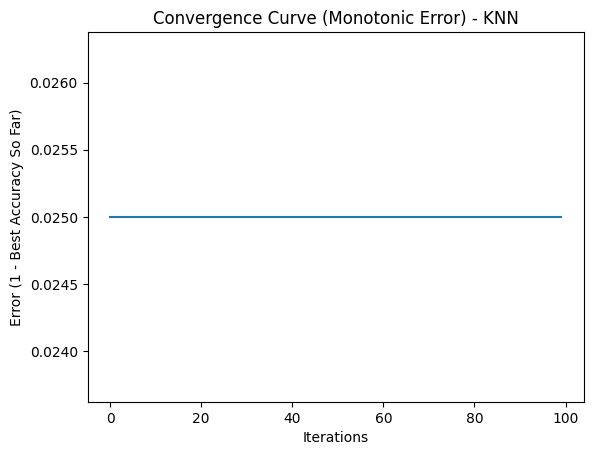

Selected Features: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 24, 26, 27, 28, 29, 30, 31, 32, 33, 35, 36]
Without FS: {'Accuracy': 0.9798657718120806, 'Precision': 0.0, 'Recall': 0.0, 'F1': 0.0}
With FS: {'Accuracy': 0.9798657718120806, 'Precision': 0.0, 'Recall': 0.0, 'F1': 0.0}

===== Running ACO for Naive Bayes =====


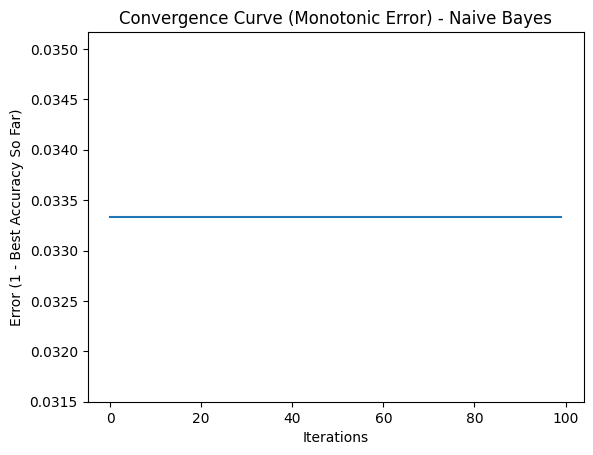

Selected Features: [0, 1, 2, 4, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 20, 21, 22, 23, 24, 25, 26, 28, 29, 30, 31, 33, 35, 36]
Without FS: {'Accuracy': 0.912751677852349, 'Precision': 0.08333333333333333, 'Recall': 0.3333333333333333, 'F1': 0.13333333333333333}
With FS: {'Accuracy': 0.912751677852349, 'Precision': 0.08333333333333333, 'Recall': 0.3333333333333333, 'F1': 0.13333333333333333}

===== Running ACO for QDA =====


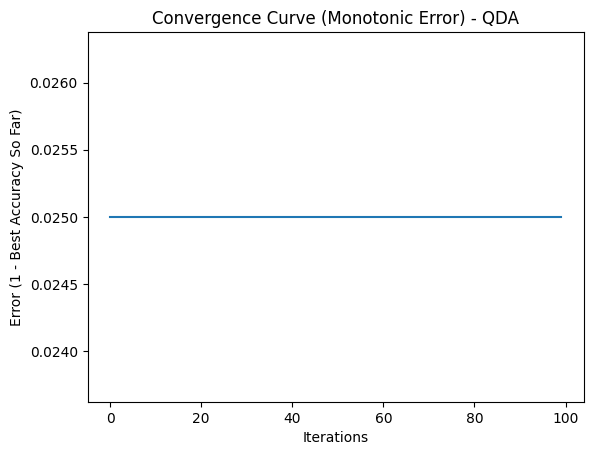

Selected Features: [0, 1, 2, 3, 4, 6, 7, 8, 9, 11, 12, 14, 15, 16, 18, 19, 20, 21, 22, 23, 24, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]
Without FS: {'Accuracy': 0.9798657718120806, 'Precision': 0.0, 'Recall': 0.0, 'F1': 0.0}
With FS: {'Accuracy': 0.9798657718120806, 'Precision': 0.0, 'Recall': 0.0, 'F1': 0.0}

===== Running ACO for Random Forest =====


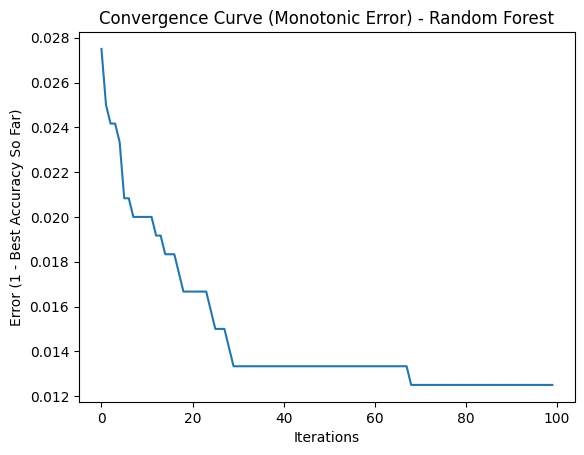

Selected Features: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 28, 29, 30, 31, 32, 33, 34, 35]
Without FS: {'Accuracy': 0.8389261744966443, 'Precision': 0.043478260869565216, 'Recall': 0.3333333333333333, 'F1': 0.07692307692307693}
With FS: {'Accuracy': 0.9060402684563759, 'Precision': 0.13333333333333333, 'Recall': 0.6666666666666666, 'F1': 0.2222222222222222}

===== FINAL RESULT TABLE =====
           Model  Accuracy (No FS)  Accuracy (With FS)  Precision    Recall  \
0            KNN          0.979866            0.979866   0.000000  0.000000   
1    Naive Bayes          0.912752            0.912752   0.083333  0.333333   
2            QDA          0.979866            0.979866   0.000000  0.000000   
3  Random Forest          0.838926            0.906040   0.133333  0.666667   

         F1  
0  0.000000  
1  0.133333  
2  0.000000  
3  0.222222  


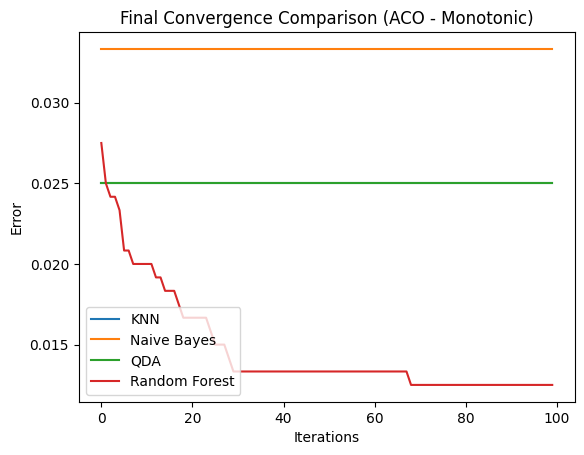


  Avg Execution Time : 429.9688 s
  Avg Memory Used    : 0.8519 MB


In [ ]:
# =========================
# FINAL WRAPPER ACO (MONOTONIC CONVERGENCE) - PC2
# =========================

import numpy as np
import pandas as pd
import random
import time
import tracemalloc
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier

# =========================
# LOAD DATA
# =========================
path = "/content/drive/MyDrive/DATASETS/csv_result-PC2.csv"
df = pd.read_csv(path)

df = df.drop(columns=['name'], errors='ignore')

target_col = df.columns[-1]

X = df.drop(columns=[target_col])
y = df[target_col].map({'N': 0, 'Y': 1})

# =========================
# SPLIT (NO DATA LEAKAGE)
# =========================
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# =========================
# MODELS
# =========================
models = {
    "KNN": KNeighborsClassifier(n_jobs=-1),
    "Naive Bayes": GaussianNB(),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1),
    "Random Forest": RandomForestClassifier(
        n_estimators=5,
        max_depth=5,
        n_jobs=-1,
        class_weight='balanced'
    )
}

# =========================
# ACO PARAMETERS
# =========================
NUM_ANTS = 10
ITERATIONS = 100
REPEATS = 10

EVAPORATION = 0.3
num_features = X_train.shape[1]

# =========================
# FITNESS (penalized)
# =========================
fitness_cache = {}

def fitness(solution, model):
    key = tuple(solution)

    if key in fitness_cache:
        return fitness_cache[key]

    if sum(solution) < 3:
        return 0

    selected = [i for i in range(len(solution)) if solution[i] == 1]

    X_tr = X_train[:, selected]
    X_v = X_val[:, selected]

    model.fit(X_tr, y_train)
    pred = model.predict(X_v)

    acc = accuracy_score(y_val, pred)

    feature_ratio = sum(solution) / num_features
    score = acc - 0.3 * feature_ratio

    fitness_cache[key] = score
    return score

# =========================
# CONSTRUCT SOLUTION
# =========================
def construct_solution(pheromone):
    solution = []

    for i in range(num_features):
        prob = pheromone[i] / (1 + pheromone[i])
        solution.append(1 if random.random() < prob else 0)

    return np.array(solution)

# =========================
# RUN ACO
# =========================
results = []
Total_time = []
Total_memory = []
model_curves = {}

for model_name, model in models.items():

    print(f"\n===== Running ACO for {model_name} =====")

    all_curves = []

    tracemalloc.start()
    start_time = time.time()

    best_global = None
    best_score = -1

    for r in range(REPEATS):

        pheromone = np.ones(num_features)
        curve = []
        best_so_far = 0   # 🔥 key for monotonic graph

        for it in range(ITERATIONS):

            solutions = []
            scores = []
            acc_list = []

            for ant in range(NUM_ANTS):
                sol = construct_solution(pheromone)

                selected = [i for i in range(len(sol)) if sol[i] == 1]

                if len(selected) < 3:
                    acc = 0
                else:
                    model.fit(X_train[:, selected], y_train)
                    pred = model.predict(X_val[:, selected])
                    acc = accuracy_score(y_val, pred)

                acc_list.append(acc)

                feature_ratio = sum(sol) / num_features
                score = acc - 0.3 * feature_ratio

                solutions.append(sol)
                scores.append(score)

            # pheromone update
            pheromone = (1 - EVAPORATION) * pheromone
            for sol, score in zip(solutions, scores):
                pheromone += score * sol

            # 🔥 MONOTONIC CONVERGENCE
            best_acc = max(acc_list)
            best_so_far = max(best_so_far, best_acc)

            curve.append(1 - best_so_far)   # error

        all_curves.append(curve)

        best_idx = np.argmax(scores)
        if scores[best_idx] > best_score:
            best_score = scores[best_idx]
            best_global = solutions[best_idx]

    # Time & Memory
    end_time = time.time()
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    Total_time.append(end_time - start_time)
    Total_memory.append(peak / 10**6)

    # Mean curve
    mean_curve = np.mean(all_curves, axis=0)
    model_curves[model_name] = mean_curve

    plt.figure()
    plt.plot(mean_curve)
    plt.title(f"Convergence Curve (Monotonic Error) - {model_name}")
    plt.xlabel("Iterations")
    plt.ylabel("Error (1 - Best Accuracy So Far)")
    plt.show()

    # Selected features
    selected_features = [i for i in range(len(best_global)) if best_global[i] == 1]
    if len(selected_features) == 0:
        selected_features = list(range(num_features))

    print("Selected Features:", selected_features)

    # =========================
    # FINAL EVALUATION
    # =========================
    def evaluate(model, X_tr, X_te):
        model.fit(X_tr, y_train_full)
        pred = model.predict(X_te)

        return {
            "Accuracy": accuracy_score(y_test, pred),
            "Precision": precision_score(y_test, pred, zero_division=0),
            "Recall": recall_score(y_test, pred, zero_division=0),
            "F1": f1_score(y_test, pred, zero_division=0)
        }

    res1 = evaluate(model, scaler.transform(X_train_full), X_test)

    X_train_fs = scaler.transform(X_train_full)[:, selected_features]
    X_test_fs = X_test[:, selected_features]

    res2 = evaluate(model, X_train_fs, X_test_fs)

    print("Without FS:", res1)
    print("With FS:", res2)

    results.append([
        model_name,
        res1["Accuracy"], res2["Accuracy"],
        res2["Precision"], res2["Recall"], res2["F1"]
    ])

# =========================
# FINAL TABLE
# =========================
final_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy (No FS)", "Accuracy (With FS)",
    "Precision", "Recall", "F1"
])

print("\n===== FINAL RESULT TABLE =====")
print(final_df)

# =========================
# FINAL CONVERGENCE GRAPH
# =========================
plt.figure()

for model_name, curve in model_curves.items():
    plt.plot(curve, label=model_name)

plt.title("Final Convergence Comparison (ACO - Monotonic)")
plt.xlabel("Iterations")
plt.ylabel("Error")
plt.legend()
plt.show()

# =========================
# TIME & MEMORY
# =========================
print(f"\n  Avg Execution Time : {np.mean(Total_time):.4f} s")
print(f"  Avg Memory Used    : {np.mean(Total_memory):.4f} MB")


===== Running ACO for KNN =====


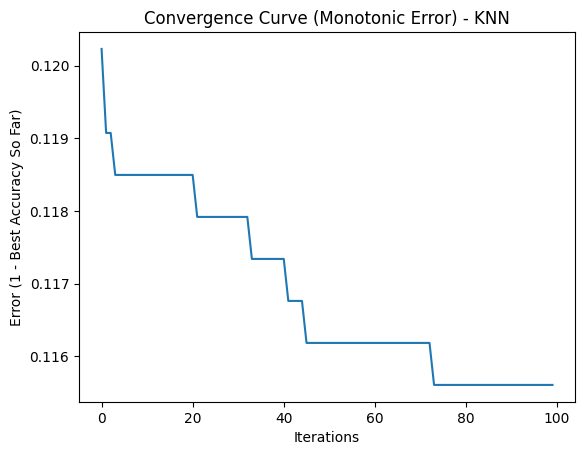

Selected Features: [1, 3, 4, 5, 6, 7, 8, 9, 10, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 27, 28, 30, 32, 33, 34, 36, 37]
Without FS: {'Accuracy': 0.8796296296296297, 'Precision': 0.5714285714285714, 'Recall': 0.14814814814814814, 'F1': 0.23529411764705882}
With FS: {'Accuracy': 0.875, 'Precision': 0.5, 'Recall': 0.14814814814814814, 'F1': 0.22857142857142856}

===== Running ACO for Naive Bayes =====


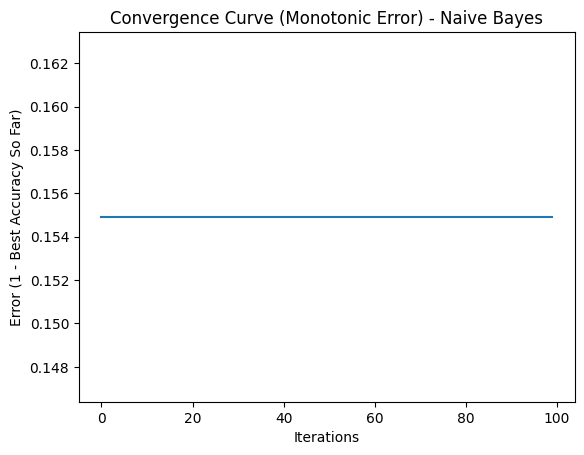

Selected Features: [0, 1, 2, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 17, 18, 19, 22, 23, 24, 25, 26, 28, 29, 31, 32, 33, 34, 35, 37]
Without FS: {'Accuracy': 0.3101851851851852, 'Precision': 0.1534090909090909, 'Recall': 1.0, 'F1': 0.2660098522167488}
With FS: {'Accuracy': 0.3888888888888889, 'Precision': 0.16981132075471697, 'Recall': 1.0, 'F1': 0.2903225806451613}

===== Running ACO for QDA =====


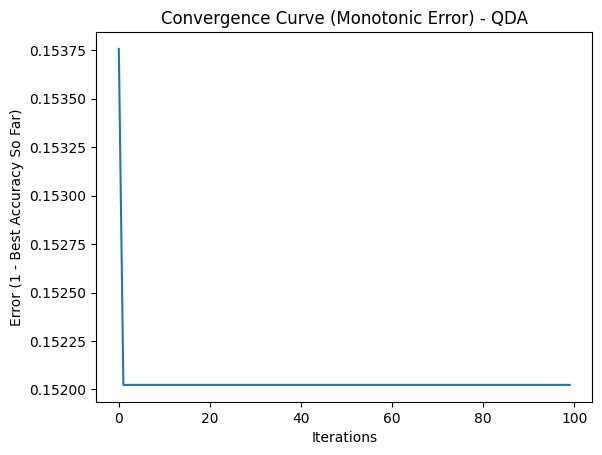

Selected Features: [1, 2, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17, 18, 19, 22, 23, 24, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37]
Without FS: {'Accuracy': 0.7037037037037037, 'Precision': 0.2823529411764706, 'Recall': 0.8888888888888888, 'F1': 0.42857142857142855}
With FS: {'Accuracy': 0.6851851851851852, 'Precision': 0.25882352941176473, 'Recall': 0.8148148148148148, 'F1': 0.39285714285714285}

===== Running ACO for Random Forest =====


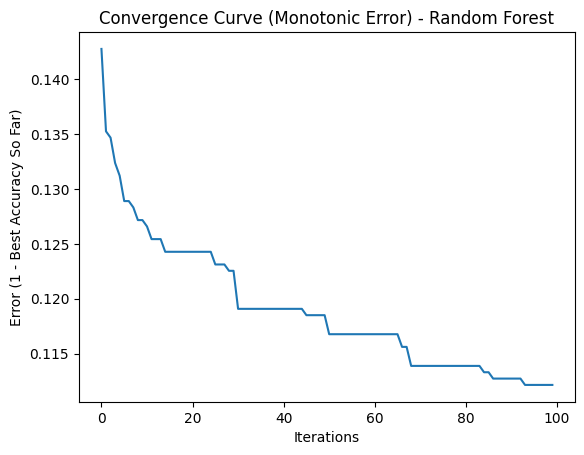

Selected Features: [0, 1, 3, 4, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 21, 22, 23, 24, 25, 26, 27, 28, 30, 32, 33, 34, 35, 36]
Without FS: {'Accuracy': 0.7962962962962963, 'Precision': 0.3111111111111111, 'Recall': 0.5185185185185185, 'F1': 0.3888888888888889}
With FS: {'Accuracy': 0.8287037037037037, 'Precision': 0.3684210526315789, 'Recall': 0.5185185185185185, 'F1': 0.4307692307692308}

===== FINAL RESULT TABLE =====
           Model  Accuracy (No FS)  Accuracy (With FS)  Precision    Recall  \
0            KNN          0.879630            0.875000   0.500000  0.148148   
1    Naive Bayes          0.310185            0.388889   0.169811  1.000000   
2            QDA          0.703704            0.685185   0.258824  0.814815   
3  Random Forest          0.796296            0.828704   0.368421  0.518519   

         F1  
0  0.228571  
1  0.290323  
2  0.392857  
3  0.430769  


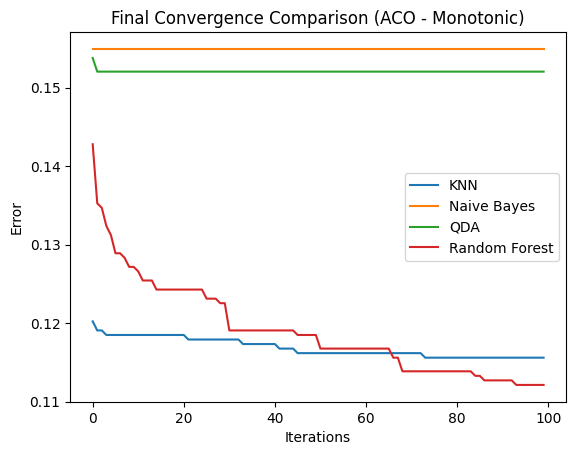


  Avg Execution Time : 440.4486 s
  Avg Memory Used    : 1.0589 MB


In [ ]:
# =========================
# FINAL WRAPPER ACO (MONOTONIC CONVERGENCE) - PC3
# =========================

import numpy as np
import pandas as pd
import random
import time
import tracemalloc
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier

# =========================
# LOAD DATA
# =========================
path = "/content/drive/MyDrive/DATASETS/csv_result-PC3.csv"
df = pd.read_csv(path)

df = df.drop(columns=['name'], errors='ignore')

target_col = df.columns[-1]

X = df.drop(columns=[target_col])
y = df[target_col].map({'N': 0, 'Y': 1})

# =========================
# SPLIT (NO DATA LEAKAGE)
# =========================
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# =========================
# MODELS
# =========================
models = {
    "KNN": KNeighborsClassifier(n_jobs=-1),
    "Naive Bayes": GaussianNB(),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1),
    "Random Forest": RandomForestClassifier(
        n_estimators=5,
        max_depth=5,
        n_jobs=-1,
        class_weight='balanced'
    )
}

# =========================
# ACO PARAMETERS
# =========================
NUM_ANTS = 10
ITERATIONS = 100
REPEATS = 10

EVAPORATION = 0.3
num_features = X_train.shape[1]

# =========================
# FITNESS (penalized)
# =========================
fitness_cache = {}

def fitness(solution, model):
    key = tuple(solution)

    if key in fitness_cache:
        return fitness_cache[key]

    if sum(solution) < 3:
        return 0

    selected = [i for i in range(len(solution)) if solution[i] == 1]

    X_tr = X_train[:, selected]
    X_v = X_val[:, selected]

    model.fit(X_tr, y_train)
    pred = model.predict(X_v)

    acc = accuracy_score(y_val, pred)

    feature_ratio = sum(solution) / num_features
    score = acc - 0.3 * feature_ratio

    fitness_cache[key] = score
    return score

# =========================
# CONSTRUCT SOLUTION
# =========================
def construct_solution(pheromone):
    solution = []

    for i in range(num_features):
        prob = pheromone[i] / (1 + pheromone[i])
        solution.append(1 if random.random() < prob else 0)

    return np.array(solution)

# =========================
# RUN ACO
# =========================
results = []
Total_time = []
Total_memory = []
model_curves = {}

for model_name, model in models.items():

    print(f"\n===== Running ACO for {model_name} =====")

    all_curves = []

    tracemalloc.start()
    start_time = time.time()

    best_global = None
    best_score = -1

    for r in range(REPEATS):

        pheromone = np.ones(num_features)
        curve = []
        best_so_far = 0   # 🔥 key for monotonic graph

        for it in range(ITERATIONS):

            solutions = []
            scores = []
            acc_list = []

            for ant in range(NUM_ANTS):
                sol = construct_solution(pheromone)

                selected = [i for i in range(len(sol)) if sol[i] == 1]

                if len(selected) < 3:
                    acc = 0
                else:
                    model.fit(X_train[:, selected], y_train)
                    pred = model.predict(X_val[:, selected])
                    acc = accuracy_score(y_val, pred)

                acc_list.append(acc)

                feature_ratio = sum(sol) / num_features
                score = acc - 0.3 * feature_ratio

                solutions.append(sol)
                scores.append(score)

            # pheromone update
            pheromone = (1 - EVAPORATION) * pheromone
            for sol, score in zip(solutions, scores):
                pheromone += score * sol

            # 🔥 MONOTONIC CONVERGENCE
            best_acc = max(acc_list)
            best_so_far = max(best_so_far, best_acc)

            curve.append(1 - best_so_far)   # error

        all_curves.append(curve)

        best_idx = np.argmax(scores)
        if scores[best_idx] > best_score:
            best_score = scores[best_idx]
            best_global = solutions[best_idx]

    # Time & Memory
    end_time = time.time()
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    Total_time.append(end_time - start_time)
    Total_memory.append(peak / 10**6)

    # Mean curve
    mean_curve = np.mean(all_curves, axis=0)
    model_curves[model_name] = mean_curve

    plt.figure()
    plt.plot(mean_curve)
    plt.title(f"Convergence Curve (Monotonic Error) - {model_name}")
    plt.xlabel("Iterations")
    plt.ylabel("Error (1 - Best Accuracy So Far)")
    plt.show()

    # Selected features
    selected_features = [i for i in range(len(best_global)) if best_global[i] == 1]
    if len(selected_features) == 0:
        selected_features = list(range(num_features))

    print("Selected Features:", selected_features)

    # =========================
    # FINAL EVALUATION
    # =========================
    def evaluate(model, X_tr, X_te):
        model.fit(X_tr, y_train_full)
        pred = model.predict(X_te)

        return {
            "Accuracy": accuracy_score(y_test, pred),
            "Precision": precision_score(y_test, pred, zero_division=0),
            "Recall": recall_score(y_test, pred, zero_division=0),
            "F1": f1_score(y_test, pred, zero_division=0)
        }

    res1 = evaluate(model, scaler.transform(X_train_full), X_test)

    X_train_fs = scaler.transform(X_train_full)[:, selected_features]
    X_test_fs = X_test[:, selected_features]

    res2 = evaluate(model, X_train_fs, X_test_fs)

    print("Without FS:", res1)
    print("With FS:", res2)

    results.append([
        model_name,
        res1["Accuracy"], res2["Accuracy"],
        res2["Precision"], res2["Recall"], res2["F1"]
    ])

# =========================
# FINAL TABLE
# =========================
final_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy (No FS)", "Accuracy (With FS)",
    "Precision", "Recall", "F1"
])

print("\n===== FINAL RESULT TABLE =====")
print(final_df)

# =========================
# FINAL CONVERGENCE GRAPH
# =========================
plt.figure()

for model_name, curve in model_curves.items():
    plt.plot(curve, label=model_name)

plt.title("Final Convergence Comparison (ACO - Monotonic)")
plt.xlabel("Iterations")
plt.ylabel("Error")
plt.legend()
plt.show()

# =========================
# TIME & MEMORY
# =========================
print(f"\n  Avg Execution Time : {np.mean(Total_time):.4f} s")
print(f"  Avg Memory Used    : {np.mean(Total_memory):.4f} MB")


===== Running ACO for KNN =====


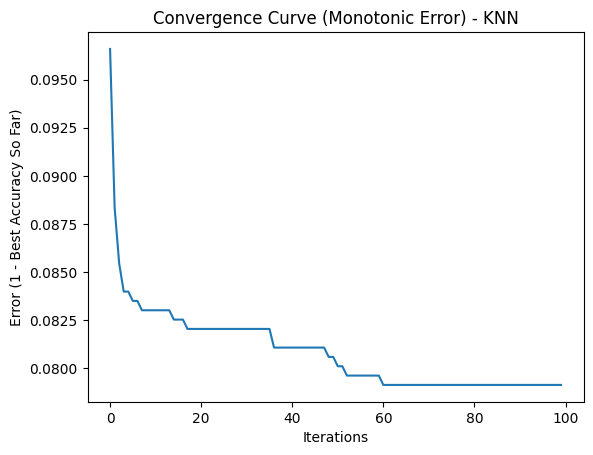

Selected Features: [0, 1, 2, 3, 4, 6, 7, 8, 9, 10, 11, 12, 13, 14, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 31, 33, 34, 35, 36, 37]
Without FS: {'Accuracy': 0.8798449612403101, 'Precision': 0.5833333333333334, 'Recall': 0.4, 'F1': 0.4745762711864407}
With FS: {'Accuracy': 0.8798449612403101, 'Precision': 0.6, 'Recall': 0.34285714285714286, 'F1': 0.43636363636363634}

===== Running ACO for Naive Bayes =====


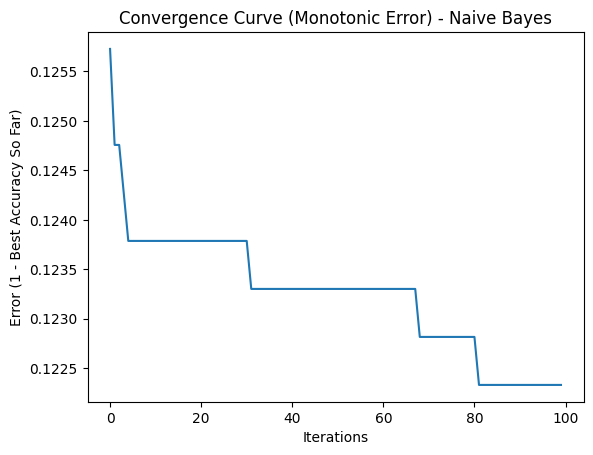

Selected Features: [0, 2, 3, 4, 5, 6, 7, 8, 9, 11, 12, 13, 14, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 28, 29, 31, 32, 33, 34, 35, 36, 37]
Without FS: {'Accuracy': 0.8604651162790697, 'Precision': 0.4782608695652174, 'Recall': 0.3142857142857143, 'F1': 0.3793103448275862}
With FS: {'Accuracy': 0.8604651162790697, 'Precision': 0.47619047619047616, 'Recall': 0.2857142857142857, 'F1': 0.35714285714285715}

===== Running ACO for QDA =====


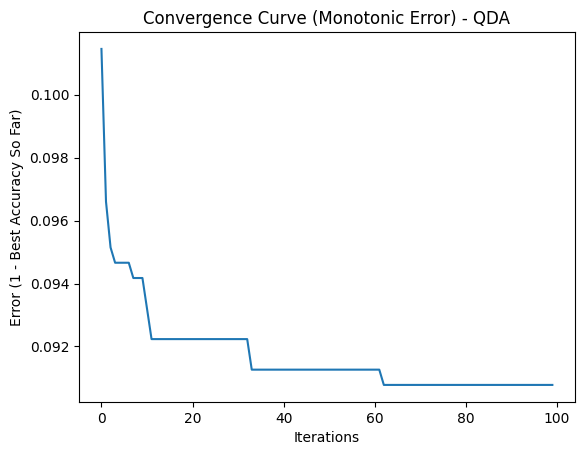

Selected Features: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 11, 12, 13, 14, 15, 17, 18, 20, 21, 22, 23, 24, 25, 27, 28, 29, 30, 31, 32, 33, 34, 36, 37]
Without FS: {'Accuracy': 0.8798449612403101, 'Precision': 0.55, 'Recall': 0.6285714285714286, 'F1': 0.5866666666666667}
With FS: {'Accuracy': 0.9186046511627907, 'Precision': 0.7916666666666666, 'Recall': 0.5428571428571428, 'F1': 0.6440677966101694}

===== Running ACO for Random Forest =====


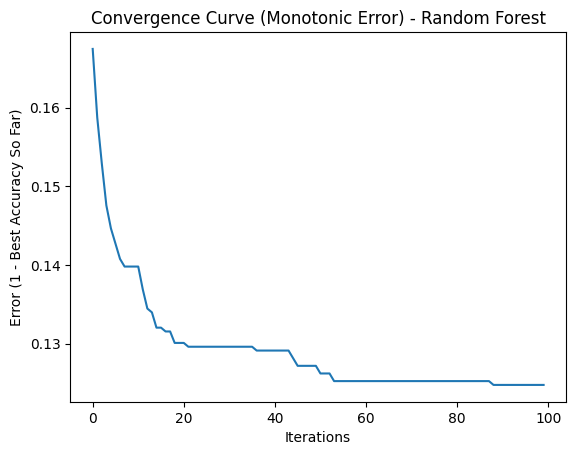

Selected Features: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 14, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37]
Without FS: {'Accuracy': 0.7868217054263565, 'Precision': 0.3717948717948718, 'Recall': 0.8285714285714286, 'F1': 0.5132743362831859}
With FS: {'Accuracy': 0.7713178294573644, 'Precision': 0.33783783783783783, 'Recall': 0.7142857142857143, 'F1': 0.45871559633027525}

===== FINAL RESULT TABLE =====
           Model  Accuracy (No FS)  Accuracy (With FS)  Precision    Recall  \
0            KNN          0.879845            0.879845   0.600000  0.342857   
1    Naive Bayes          0.860465            0.860465   0.476190  0.285714   
2            QDA          0.879845            0.918605   0.791667  0.542857   
3  Random Forest          0.786822            0.771318   0.337838  0.714286   

         F1  
0  0.436364  
1  0.357143  
2  0.644068  
3  0.458716  


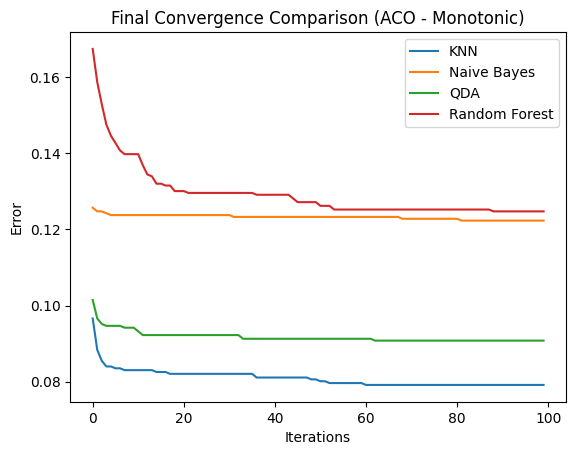


  Avg Execution Time : 444.2705 s
  Avg Memory Used    : 1.1181 MB


In [ ]:
# =========================
# FINAL WRAPPER ACO (MONOTONIC CONVERGENCE) - PC4
# =========================

import numpy as np
import pandas as pd
import random
import time
import tracemalloc
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier

# =========================
# LOAD DATA
# =========================
path = "/content/drive/MyDrive/DATASETS/csv_result-PC4.csv"
df = pd.read_csv(path)

df = df.drop(columns=['name'], errors='ignore')

target_col = df.columns[-1]

X = df.drop(columns=[target_col])
y = df[target_col].map({'N': 0, 'Y': 1})

# =========================
# SPLIT (NO DATA LEAKAGE)
# =========================
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# =========================
# MODELS
# =========================
models = {
    "KNN": KNeighborsClassifier(n_jobs=-1),
    "Naive Bayes": GaussianNB(),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1),
    "Random Forest": RandomForestClassifier(
        n_estimators=5,
        max_depth=5,
        n_jobs=-1,
        class_weight='balanced'
    )
}

# =========================
# ACO PARAMETERS
# =========================
NUM_ANTS = 10
ITERATIONS = 100
REPEATS = 10

EVAPORATION = 0.3
num_features = X_train.shape[1]

# =========================
# FITNESS (penalized)
# =========================
fitness_cache = {}

def fitness(solution, model):
    key = tuple(solution)

    if key in fitness_cache:
        return fitness_cache[key]

    if sum(solution) < 3:
        return 0

    selected = [i for i in range(len(solution)) if solution[i] == 1]

    X_tr = X_train[:, selected]
    X_v = X_val[:, selected]

    model.fit(X_tr, y_train)
    pred = model.predict(X_v)

    acc = accuracy_score(y_val, pred)

    feature_ratio = sum(solution) / num_features
    score = acc - 0.3 * feature_ratio

    fitness_cache[key] = score
    return score

# =========================
# CONSTRUCT SOLUTION
# =========================
def construct_solution(pheromone):
    solution = []

    for i in range(num_features):
        prob = pheromone[i] / (1 + pheromone[i])
        solution.append(1 if random.random() < prob else 0)

    return np.array(solution)

# =========================
# RUN ACO
# =========================
results = []
Total_time = []
Total_memory = []
model_curves = {}

for model_name, model in models.items():

    print(f"\n===== Running ACO for {model_name} =====")

    all_curves = []

    tracemalloc.start()
    start_time = time.time()

    best_global = None
    best_score = -1

    for r in range(REPEATS):

        pheromone = np.ones(num_features)
        curve = []
        best_so_far = 0   # 🔥 key for monotonic graph

        for it in range(ITERATIONS):

            solutions = []
            scores = []
            acc_list = []

            for ant in range(NUM_ANTS):
                sol = construct_solution(pheromone)

                selected = [i for i in range(len(sol)) if sol[i] == 1]

                if len(selected) < 3:
                    acc = 0
                else:
                    model.fit(X_train[:, selected], y_train)
                    pred = model.predict(X_val[:, selected])
                    acc = accuracy_score(y_val, pred)

                acc_list.append(acc)

                feature_ratio = sum(sol) / num_features
                score = acc - 0.3 * feature_ratio

                solutions.append(sol)
                scores.append(score)

            # pheromone update
            pheromone = (1 - EVAPORATION) * pheromone
            for sol, score in zip(solutions, scores):
                pheromone += score * sol

            # 🔥 MONOTONIC CONVERGENCE
            best_acc = max(acc_list)
            best_so_far = max(best_so_far, best_acc)

            curve.append(1 - best_so_far)   # error

        all_curves.append(curve)

        best_idx = np.argmax(scores)
        if scores[best_idx] > best_score:
            best_score = scores[best_idx]
            best_global = solutions[best_idx]

    # Time & Memory
    end_time = time.time()
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    Total_time.append(end_time - start_time)
    Total_memory.append(peak / 10**6)

    # Mean curve
    mean_curve = np.mean(all_curves, axis=0)
    model_curves[model_name] = mean_curve

    plt.figure()
    plt.plot(mean_curve)
    plt.title(f"Convergence Curve (Monotonic Error) - {model_name}")
    plt.xlabel("Iterations")
    plt.ylabel("Error (1 - Best Accuracy So Far)")
    plt.show()

    # Selected features
    selected_features = [i for i in range(len(best_global)) if best_global[i] == 1]
    if len(selected_features) == 0:
        selected_features = list(range(num_features))

    print("Selected Features:", selected_features)

    # =========================
    # FINAL EVALUATION
    # =========================
    def evaluate(model, X_tr, X_te):
        model.fit(X_tr, y_train_full)
        pred = model.predict(X_te)

        return {
            "Accuracy": accuracy_score(y_test, pred),
            "Precision": precision_score(y_test, pred, zero_division=0),
            "Recall": recall_score(y_test, pred, zero_division=0),
            "F1": f1_score(y_test, pred, zero_division=0)
        }

    res1 = evaluate(model, scaler.transform(X_train_full), X_test)

    X_train_fs = scaler.transform(X_train_full)[:, selected_features]
    X_test_fs = X_test[:, selected_features]

    res2 = evaluate(model, X_train_fs, X_test_fs)

    print("Without FS:", res1)
    print("With FS:", res2)

    results.append([
        model_name,
        res1["Accuracy"], res2["Accuracy"],
        res2["Precision"], res2["Recall"], res2["F1"]
    ])

# =========================
# FINAL TABLE
# =========================
final_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy (No FS)", "Accuracy (With FS)",
    "Precision", "Recall", "F1"
])

print("\n===== FINAL RESULT TABLE =====")
print(final_df)

# =========================
# FINAL CONVERGENCE GRAPH
# =========================
plt.figure()

for model_name, curve in model_curves.items():
    plt.plot(curve, label=model_name)

plt.title("Final Convergence Comparison (ACO - Monotonic)")
plt.xlabel("Iterations")
plt.ylabel("Error")
plt.legend()
plt.show()

# =========================
# TIME & MEMORY
# =========================
print(f"\n  Avg Execution Time : {np.mean(Total_time):.4f} s")
print(f"  Avg Memory Used    : {np.mean(Total_memory):.4f} MB")


===== Running ACO for KNN =====


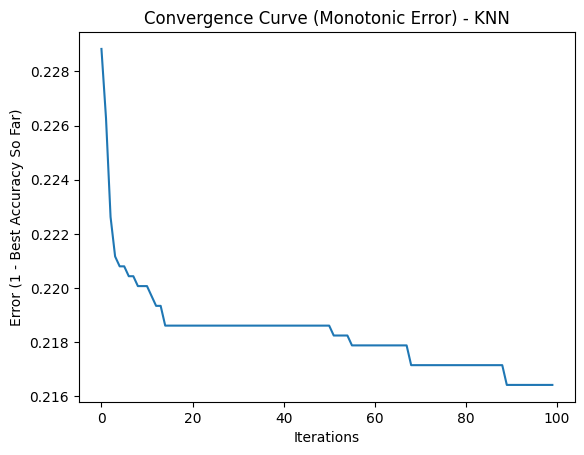

Selected Features: [0, 1, 2, 3, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 21, 22, 23, 24, 25, 26, 28, 29, 31, 32, 33, 34, 35, 37, 38]
Without FS: {'Accuracy': 0.760932944606414, 'Precision': 0.5882352941176471, 'Recall': 0.425531914893617, 'F1': 0.49382716049382713}
With FS: {'Accuracy': 0.7638483965014577, 'Precision': 0.5915492957746479, 'Recall': 0.44680851063829785, 'F1': 0.509090909090909}

===== Running ACO for Naive Bayes =====


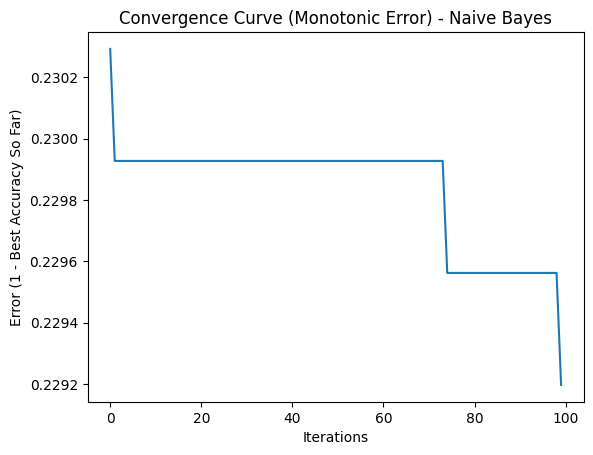

Selected Features: [0, 1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17, 18, 19, 20, 22, 23, 24, 25, 26, 27, 28, 29, 31, 32, 34, 35, 37]
Without FS: {'Accuracy': 0.749271137026239, 'Precision': 0.6176470588235294, 'Recall': 0.22340425531914893, 'F1': 0.328125}
With FS: {'Accuracy': 0.749271137026239, 'Precision': 0.6052631578947368, 'Recall': 0.24468085106382978, 'F1': 0.3484848484848485}

===== Running ACO for QDA =====


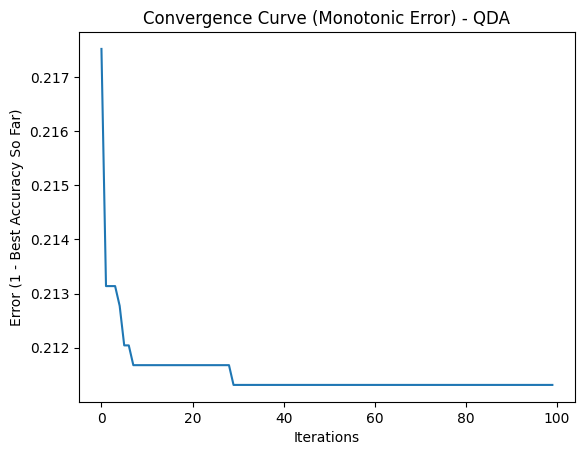

Selected Features: [0, 1, 2, 3, 4, 6, 7, 8, 11, 12, 14, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 31, 32, 33, 35, 36, 38]
Without FS: {'Accuracy': 0.7405247813411079, 'Precision': 0.5641025641025641, 'Recall': 0.23404255319148937, 'F1': 0.3308270676691729}
With FS: {'Accuracy': 0.7346938775510204, 'Precision': 0.5348837209302325, 'Recall': 0.24468085106382978, 'F1': 0.3357664233576642}

===== Running ACO for Random Forest =====


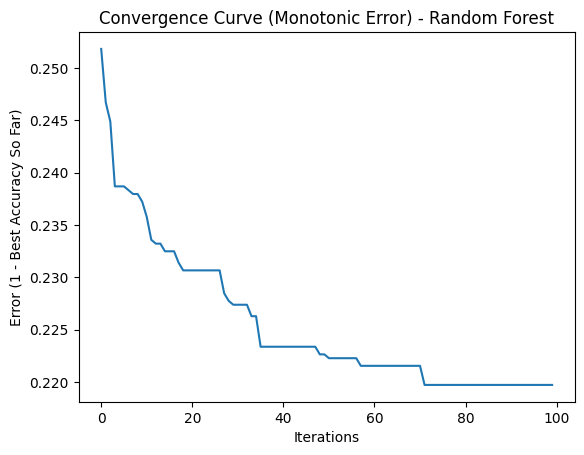

Selected Features: [0, 1, 2, 4, 5, 6, 7, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38]
Without FS: {'Accuracy': 0.6967930029154519, 'Precision': 0.4652777777777778, 'Recall': 0.7127659574468085, 'F1': 0.5630252100840336}
With FS: {'Accuracy': 0.6705539358600583, 'Precision': 0.4326241134751773, 'Recall': 0.648936170212766, 'F1': 0.5191489361702127}

===== FINAL RESULT TABLE =====
           Model  Accuracy (No FS)  Accuracy (With FS)  Precision    Recall  \
0            KNN          0.760933            0.763848   0.591549  0.446809   
1    Naive Bayes          0.749271            0.749271   0.605263  0.244681   
2            QDA          0.740525            0.734694   0.534884  0.244681   
3  Random Forest          0.696793            0.670554   0.432624  0.648936   

         F1  
0  0.509091  
1  0.348485  
2  0.335766  
3  0.519149  


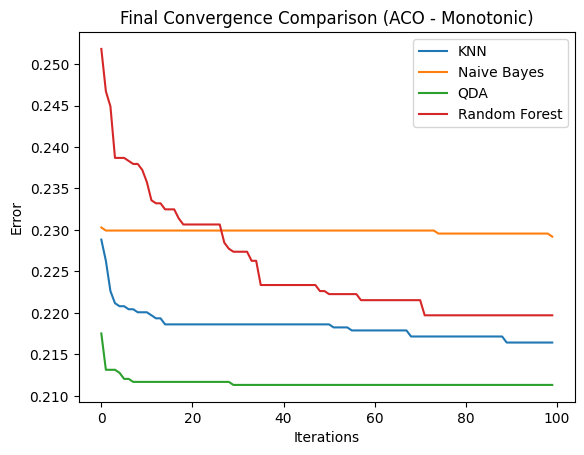


  Avg Execution Time : 456.5961 s
  Avg Memory Used    : 1.2853 MB


In [ ]:
# =========================
# FINAL WRAPPER ACO (MONOTONIC CONVERGENCE) - PC5
# =========================

import numpy as np
import pandas as pd
import random
import time
import tracemalloc
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier

# =========================
# LOAD DATA
# =========================
path = "/content/drive/MyDrive/DATASETS/csv_result-PC5.csv"
df = pd.read_csv(path)

df = df.drop(columns=['name'], errors='ignore')

target_col = df.columns[-1]

X = df.drop(columns=[target_col])
y = df[target_col].map({'N': 0, 'Y': 1})

# =========================
# SPLIT (NO DATA LEAKAGE)
# =========================
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# =========================
# MODELS
# =========================
models = {
    "KNN": KNeighborsClassifier(n_jobs=-1),
    "Naive Bayes": GaussianNB(),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1),
    "Random Forest": RandomForestClassifier(
        n_estimators=5,
        max_depth=5,
        n_jobs=-1,
        class_weight='balanced'
    )
}

# =========================
# ACO PARAMETERS
# =========================
NUM_ANTS = 10
ITERATIONS = 100
REPEATS = 10

EVAPORATION = 0.3
num_features = X_train.shape[1]

# =========================
# FITNESS (penalized)
# =========================
fitness_cache = {}

def fitness(solution, model):
    key = tuple(solution)

    if key in fitness_cache:
        return fitness_cache[key]

    if sum(solution) < 3:
        return 0

    selected = [i for i in range(len(solution)) if solution[i] == 1]

    X_tr = X_train[:, selected]
    X_v = X_val[:, selected]

    model.fit(X_tr, y_train)
    pred = model.predict(X_v)

    acc = accuracy_score(y_val, pred)

    feature_ratio = sum(solution) / num_features
    score = acc - 0.3 * feature_ratio

    fitness_cache[key] = score
    return score

# =========================
# CONSTRUCT SOLUTION
# =========================
def construct_solution(pheromone):
    solution = []

    for i in range(num_features):
        prob = pheromone[i] / (1 + pheromone[i])
        solution.append(1 if random.random() < prob else 0)

    return np.array(solution)

# =========================
# RUN ACO
# =========================
results = []
Total_time = []
Total_memory = []
model_curves = {}

for model_name, model in models.items():

    print(f"\n===== Running ACO for {model_name} =====")

    all_curves = []

    tracemalloc.start()
    start_time = time.time()

    best_global = None
    best_score = -1

    for r in range(REPEATS):

        pheromone = np.ones(num_features)
        curve = []
        best_so_far = 0   # 🔥 key for monotonic graph

        for it in range(ITERATIONS):

            solutions = []
            scores = []
            acc_list = []

            for ant in range(NUM_ANTS):
                sol = construct_solution(pheromone)

                selected = [i for i in range(len(sol)) if sol[i] == 1]

                if len(selected) < 3:
                    acc = 0
                else:
                    model.fit(X_train[:, selected], y_train)
                    pred = model.predict(X_val[:, selected])
                    acc = accuracy_score(y_val, pred)

                acc_list.append(acc)

                feature_ratio = sum(sol) / num_features
                score = acc - 0.3 * feature_ratio

                solutions.append(sol)
                scores.append(score)

            # pheromone update
            pheromone = (1 - EVAPORATION) * pheromone
            for sol, score in zip(solutions, scores):
                pheromone += score * sol

            # 🔥 MONOTONIC CONVERGENCE
            best_acc = max(acc_list)
            best_so_far = max(best_so_far, best_acc)

            curve.append(1 - best_so_far)   # error

        all_curves.append(curve)

        best_idx = np.argmax(scores)
        if scores[best_idx] > best_score:
            best_score = scores[best_idx]
            best_global = solutions[best_idx]

    # Time & Memory
    end_time = time.time()
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    Total_time.append(end_time - start_time)
    Total_memory.append(peak / 10**6)

    # Mean curve
    mean_curve = np.mean(all_curves, axis=0)
    model_curves[model_name] = mean_curve

    plt.figure()
    plt.plot(mean_curve)
    plt.title(f"Convergence Curve (Monotonic Error) - {model_name}")
    plt.xlabel("Iterations")
    plt.ylabel("Error (1 - Best Accuracy So Far)")
    plt.show()

    # Selected features
    selected_features = [i for i in range(len(best_global)) if best_global[i] == 1]
    if len(selected_features) == 0:
        selected_features = list(range(num_features))

    print("Selected Features:", selected_features)

    # =========================
    # FINAL EVALUATION
    # =========================
    def evaluate(model, X_tr, X_te):
        model.fit(X_tr, y_train_full)
        pred = model.predict(X_te)

        return {
            "Accuracy": accuracy_score(y_test, pred),
            "Precision": precision_score(y_test, pred, zero_division=0),
            "Recall": recall_score(y_test, pred, zero_division=0),
            "F1": f1_score(y_test, pred, zero_division=0)
        }

    res1 = evaluate(model, scaler.transform(X_train_full), X_test)

    X_train_fs = scaler.transform(X_train_full)[:, selected_features]
    X_test_fs = X_test[:, selected_features]

    res2 = evaluate(model, X_train_fs, X_test_fs)

    print("Without FS:", res1)
    print("With FS:", res2)

    results.append([
        model_name,
        res1["Accuracy"], res2["Accuracy"],
        res2["Precision"], res2["Recall"], res2["F1"]
    ])

# =========================
# FINAL TABLE
# =========================
final_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy (No FS)", "Accuracy (With FS)",
    "Precision", "Recall", "F1"
])

print("\n===== FINAL RESULT TABLE =====")
print(final_df)

# =========================
# FINAL CONVERGENCE GRAPH
# =========================
plt.figure()

for model_name, curve in model_curves.items():
    plt.plot(curve, label=model_name)

plt.title("Final Convergence Comparison (ACO - Monotonic)")
plt.xlabel("Iterations")
plt.ylabel("Error")
plt.legend()
plt.show()

# =========================
# TIME & MEMORY
# =========================
print(f"\n  Avg Execution Time : {np.mean(Total_time):.4f} s")
print(f"  Avg Memory Used    : {np.mean(Total_memory):.4f} MB")